<a href="https://colab.research.google.com/github/tatsuro-jp-oka/Head-Impact/blob/main/Head_Impact_OpenRadioss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
#  Pedestrian Head Impact / OpenRadioss  -  CELL 1 : configuration & environment
#  TEST_MODE gives a small, fast model for debugging the whole chain.
#  Cost of an explicit run ~ (number of elements) x (T_END / time step),
#  so the switches below attack all three factors at once.
# =============================================================================
TEST_MODE = False           # True = fast debug run, False = production run

CFG = dict(
    # ---- impact conditions --------------------------------------------------
    T_END      = 0.060,    # [s]   simulated time (contact must finish inside it)
    V_IMPACT   = 11.1,     # [m/s] 40 km/h
    ANGLE_DEG  = 65.0,     # [deg] 65 = Euro NCAP adult headform, 90 = vertical
    HEAD_MASS  = 4.5,      # [kg]
    HEAD_R     = 82.5,     # [mm]  adult headform radius (165 mm dia.)
    GAP        = 3.0,      # [mm]  stand-off measured ALONG the velocity vector
    # ---- model extraction ---------------------------------------------------
    HOOD_PIDS  = [2000292, 2000295],
    TITLE_KEYS = ("hood", "bonnet"),
    ELFORM     = 16,       # 16 = QEPH (hourglass free), 2 = Belytschko-Tsay
    CONTACT_SOFT = 0,      # 0 = omit optional card A, 2 = SOFT=2 formulation
    USE_SRC_CURVE = True,  # reuse *DEFINE_CURVE / EPS-ES of the source deck
    HARD_K = 400.0, HARD_N = 0.5,   # fallback law: sigma = SIGY + K*eps_p^n
    # ---- size reduction (the strongest lever on run time) -------------------
    CROP_R     = 0.0,      # [mm] >0 : keep only the disc of this radius around
                           #      the impact point. 0 = keep the whole hood.
                           #      Rule of thumb: >= 2.5 headform diameters (410 mm)
    HEADFORM_NLAT = 20,    # headform mesh density (lat x lon)
    HEADFORM_NLON = 32,
    # ---- support conditions -------------------------------------------------
    #  "clamp"       : whole outline fixed, 6 dof   -> stiffest, screening only
    #  "pin"         : whole outline fixed, 3 dof   -> slightly softer
    #  "hinge_latch" : 2 hinges + 1 latch + 2 bump stops -> closest to the car
    #  NOTE: a cropped model has no hinge or latch left, so it is forced to clamp
    SPC_MODE   = "hinge_latch",
    EDGE_BAND  = 15.0,     # [mm] width of the clamped band (clamp / pin / crop)
    ATTACH_R   = 40.0,     # [mm] radius of each attachment patch (hinge_latch)
    # ---- panel joining ------------------------------------------------------
    HEM_TIE    = True,     # tie outer/inner flanges around the outline (hemming)
    HEM_BAND   = 25.0,     # [mm] band from the outline where the hem is searched
    HEM_GAP    = 8.0,      # [mm] max outer-inner distance accepted as a hem
    HEM_PITCH  = 25.0,     # [mm] spacing between hem ties (keeps the count sane)
    MASTIC_TIE = False,    # tie the panels in the interior (adhesive pads)
    MASTIC_GAP = 15.0,     # [mm] max outer-inner distance accepted as mastic
    MASTIC_PITCH = 200.0,  # [mm] spacing between mastic pads
    # ---- optional obstacle --------------------------------------------------
    HARDPOINT  = 0.0,      # >0 : rigid wall this many mm below the impact point
    # ---- contact ------------------------------------------------------------
    SELF_CONTACT = True,   # hood self contact: needed once the panel buckles,
                           #                    expensive, droppable for a test
    # ---- solver / output ----------------------------------------------------
    NTHR      = 0,         # 0 = use every core the Colab VM actually has
    USE_SP    = False,     # use the single precision binaries when available
    PARITH_OFF = False,    # non-deterministic summation, a few percent faster
    DT_SCALE  = 0.8,       # mass scaling target = DT_SCALE * dt0.
                           #  <1   : practically no added mass
                           #  1.5  : ~1.9x fewer cycles, watch the added mass
    ANIM_DT   = 2.5e-4,    # [s] animation = visualisation only  -> coarse
    TH_DT     = 1.0e-5,    # [s] time history = signal source    -> 100 kHz
    CFC       = 1000.0,    # SAE J211 channel frequency class
    HIC_WIN   = 0.015,     # [s] HIC15
    MASS_SCALE_MAX = 0.02, # warn if the added mass exceeds this fraction
    MAX_MIN   = 45,        # wall-clock limit for the engine
)

# ---- fast debug preset ------------------------------------------------------
TEST_OVERRIDE = dict(
    T_END        = 0.008,  # first contact peak only; HIC will NOT be valid
    CROP_R       = 400.0,  # ~2.4 headform diameters around the impact point
    DT_SCALE     = 1.5,    # roughly halves the cycle count
    SELF_CONTACT = False,  # the panel barely buckles within 8 ms
    HEADFORM_NLAT = 14, HEADFORM_NLON = 24,
    ANIM_DT      = 5.0e-4,
    TH_DT        = 2.0e-5, # 50 kHz, still fine for CFC1000
    USE_SP       = True,
    PARITH_OFF   = True,
    MAX_MIN      = 12,
)
if TEST_MODE:
    CFG.update(TEST_OVERRIDE)
CFG["TEST_MODE"] = TEST_MODE
assert CFG["SPC_MODE"] in ("clamp", "pin", "hinge_latch")

import os, re, sys, glob, json, math, time, shutil, subprocess, zipfile, tarfile
import urllib.request
BAN = lambda s: print("\n" + "=" * 66 + f"\n  {s}\n" + "=" * 66, flush=True)
sh  = lambda c, **k: subprocess.run(c, shell=isinstance(c, str),
                                    capture_output=True, text=True, **k)
BAN("CELL 1  config / drive / OpenRadioss" + ("   [TEST MODE]" if TEST_MODE else ""))

from google.colab import drive
if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive")
DRV  = "/content/drive/MyDrive/head_impact_radioss"
WORK = DRV + "/work"
OUTD = DRV + "/" + time.strftime("%Y%m%d_%H%M%S") + ("_test" if TEST_MODE else "")
OR, DECKD, RUN = "/content/OpenRadioss", "/content/radioss", "/content/hood_run"
DECK, JOB = DECKD + "/head_impact.key", "head_impact"
for d in (DRV, WORK, OUTD, DECKD, RUN):
    os.makedirs(d, exist_ok=True)

fx = lambda p: sorted(q for q in glob.glob(OR + "/**/" + p, recursive=True)
                      if os.path.isfile(q))

# ---- install OpenRadioss (the archive is cached in Drive after the 1st run)
if not fx("starter_linux64*"):
    arc = sorted(glob.glob(WORK + "/OpenRadioss*linux64*")) + \
          sorted(glob.glob(WORK + "/OpenRadioss*.zip"))
    if not arc:
        print("  fetching the latest GitHub release ...", flush=True)
        rel = json.load(urllib.request.urlopen(
            "https://api.github.com/repos/OpenRadioss/OpenRadioss/releases/latest"))
        a = [x for x in rel["assets"] if "linux64" in x["name"].lower()
             and x["name"].lower().endswith((".zip", ".tar.gz"))][0]
        dst = WORK + "/" + a["name"]
        sh(["wget", "-q", "-O", dst, a["browser_download_url"]])
        arc = [dst]
    src = arc[0]
    print(f"  archive: {src} ({os.path.getsize(src)/1e6:.1f} MB)")
    tmp = "/content/_or_tmp"
    shutil.rmtree(tmp, ignore_errors=True); os.makedirs(tmp)
    (zipfile.ZipFile(src).extractall if src.endswith(".zip")
     else tarfile.open(src).extractall)(tmp)
    root = next((os.path.dirname(os.path.dirname(p))
                 for p in glob.glob(tmp + "/**/starter_linux64*", recursive=True)), None)
    assert root, "no starter binary inside the archive"
    shutil.rmtree(OR, ignore_errors=True); shutil.move(root, OR)

for p in glob.glob(OR + "/**/*_linux64*", recursive=True):
    if os.path.isfile(p):
        os.chmod(p, 0o755)

# ---- pick the precision : starter and engine must always match -------------
def pick(stem, want_sp):
    cand = fx(stem + "_linux64*")
    sp = [c for c in cand if c.endswith("_sp")]
    dp = [c for c in cand if not c.endswith("_sp")]
    if want_sp and sp:
        return sp[0], True
    assert dp, f"{stem} binary not found"
    return dp[0], False
ST, sp_a = pick("starter", CFG["USE_SP"])
EN, sp_b = pick("engine",  CFG["USE_SP"])
if sp_a != sp_b:                     # never mix precisions
    ST, _ = pick("starter", False); EN, _ = pick("engine", False); sp_a = False
PREC = "single" if sp_a else "double"
if CFG["USE_SP"] and not sp_a:
    print("  single precision binaries not in this release -> double precision")

# ---- thread count : Colab usually has only 2 vCPU, oversubscription hurts --
NCPU = os.cpu_count() or 2
CFG["NTHR"] = NCPU if CFG["NTHR"] in (0, None) else min(CFG["NTHR"], NCPU)

# ---- locate the post-processing helpers now, so CELL 5/6 never have to guess
A2V = next(iter(fx("*anim*vtk*")), None)     # anim_to_vtk : A-file -> legacy VTK
T2C = next(iter(fx("*th_to_csv*")), None)    # th_to_csv   : T-file -> csv
CFGD = next((p for p in glob.glob(OR + "/**/hm_cfg_files", recursive=True)),
            OR + "/hm_cfg_files")
SOD = sorted({os.path.dirname(p) for p in glob.glob(OR + "/**/*.so*", recursive=True)})
os.environ.update(OPENRADIOSS_PATH=OR, RAD_CFG_PATH=CFGD,
                  LD_LIBRARY_PATH=":".join(SOD + [os.environ.get("LD_LIBRARY_PATH", "")]),
                  OMP_NUM_THREADS=str(CFG["NTHR"]), OMP_STACKSIZE="400m")

miss = [l.strip() for l in sh(["ldd", ST]).stdout.splitlines() if "not found" in l]
if miss:
    sh("apt-get -qq install -y libgfortran5 libgomp1 >/dev/null 2>&1")
    miss = [l.strip() for l in sh(["ldd", ST]).stdout.splitlines() if "not found" in l]
assert not miss, "unresolved shared libraries:\n" + "\n".join(miss)

S = dict(OR=OR, ST=ST, EN=EN, A2V=A2V, T2C=T2C, PREC=PREC, NCPU=NCPU,
         DECKD=DECKD, DECK=DECK, RUN=RUN, JOB=JOB,
         DRV=DRV, WORK=WORK, OUTD=OUTD, CFG=CFG)
json.dump(S, open("/content/state.json", "w"), indent=1)
print(f"  starter    : {ST}")
print(f"  engine     : {EN}   ({PREC} precision)")
print(f"  anim_to_vtk: {A2V}\n  th_to_csv  : {T2C}")
print(f"  cfg dir    : {CFGD}    so dirs: {len(SOD)}    ldd OK")
print(f"  cores      : {NCPU} detected -> NTHR={CFG['NTHR']}")
print(f"  OUTD       : {OUTD}")
print(f"  support {CFG['SPC_MODE']} | hem {CFG['HEM_TIE']} | "
      f"self contact {CFG['SELF_CONTACT']} | crop {CFG['CROP_R'] or 'none'} mm")
print(f"  angle {CFG['ANGLE_DEG']} deg | T_END {CFG['T_END']*1e3:.1f} ms | "
      f"dt target {CFG['DT_SCALE']}*dt0 | TH_DT {CFG['TH_DT']:.1e} s | "
      f"ANIM_DT {CFG['ANIM_DT']:.1e} s")
if TEST_MODE:
    print("  !! TEST MODE : cropped model, short T_END, extra mass scaling.")
    print("     HIC and rebound are NOT valid - use it only to debug the chain.")
if not T2C:
    print("  !! th_to_csv not found -> CELL 5 will fall back to the ANIM signal")



  CELL 1  config / drive / OpenRadioss
  starter    : /content/OpenRadioss/exec/starter_linux64_gf
  engine     : /content/OpenRadioss/exec/engine_linux64_gf   (double precision)
  anim_to_vtk: /content/OpenRadioss/exec/anim_to_vtk_linux64_gf
  th_to_csv  : /content/OpenRadioss/exec/th_to_csv_linux64_gf
  cfg dir    : /content/OpenRadioss/hm_cfg_files    so dirs: 2    ldd OK
  cores      : 8 detected -> NTHR=8
  OUTD       : /content/drive/MyDrive/head_impact_radioss/20260920_083314
  support hinge_latch | hem True | self contact True | crop none mm
  angle 65.0 deg | T_END 60.0 ms | dt target 0.8*dt0 | TH_DT 1.0e-05 s | ANIM_DT 2.5e-04 s


  CELL 2  deck
  source: /content/drive/MyDrive/2012-toyota-camry-detailed-v5a/2012-toyota-camry-detailed-v5a/camry-detailed-v5a.key  (248.4 MB)
  PART=1086  SECTION=996  MAT=1083  CURVE=17
  hood PID: [2000292, 2000295]  ['387_hoodouter', '386_hoodinner']
  shell=36830  node=36386
  units: ton-mm-s  RO=7.85e-09  V=11100  T_END=0.06
  hood bbox  = [1128.3 1547.6  260.3] mm
  hood mass  = 17.256 kg (full panel)
  support mode = hinge_latch   (cowl side = -x)
    hinge_L        nodes=   88  dof=111000
    hinge_R        nodes=   88  dof=111000
    latch          nodes=   95  dof=111000
    bumpstop_L     nodes=   89  dof=001000
    bumpstop_R     nodes=   87  dof=001000
  panel ties: hem=253  mastic=0
  impact ctr = (-629.1, -0.7, 1035.7)  z_top=958.2  stand-off=3.0 mm along v
  velocity   = (-4691.1, 0, -10060.0)  angle=65.0 deg
  nearest support is 481 mm away (2.9 headform diameters; 3 or more is desirable)
  headform node=611 elem=640 rho=2.647e-08 E0=277.2 J
  MID 2000292: E=2.1e+05

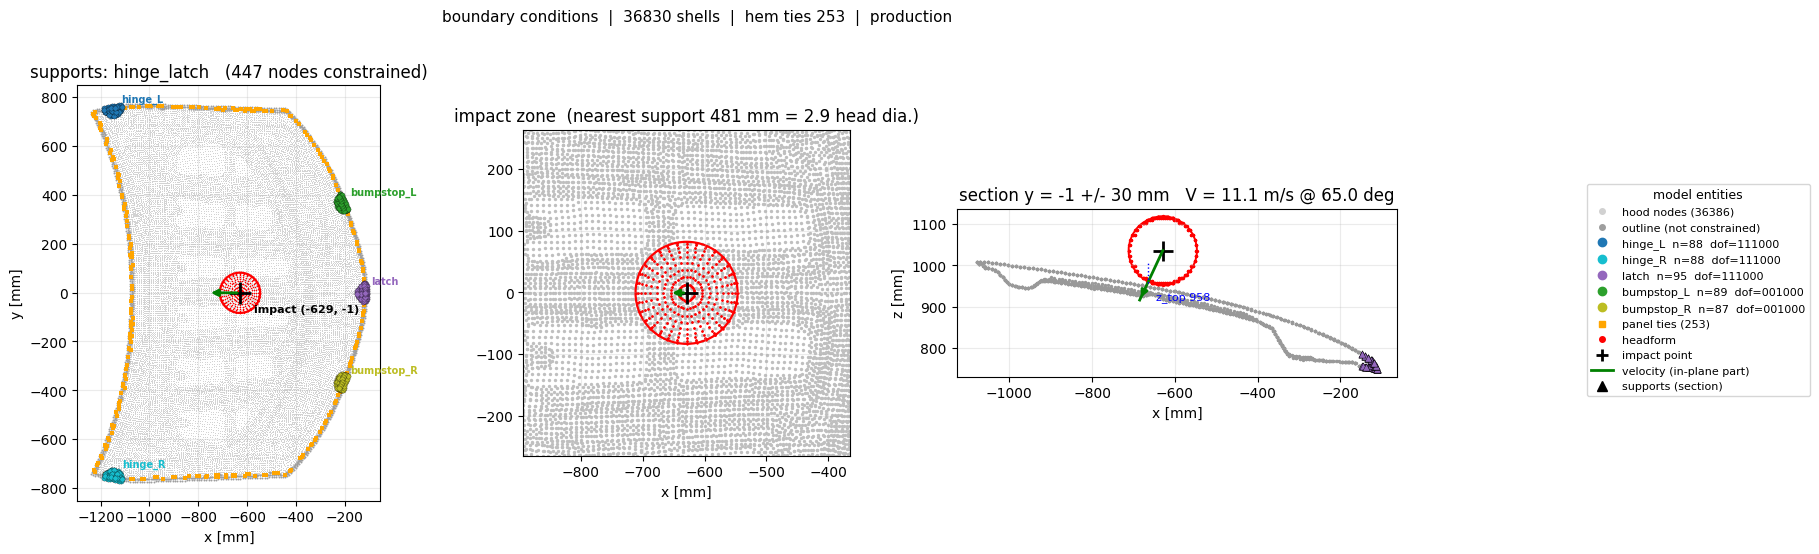


  support positions (centroid of each set)
    hinge_L        n=   88  dof=111000  centroid=( -1149.0,   745.7,   970.8)  distance to impact =    910 mm
    hinge_R        n=   88  dof=111000  centroid=( -1147.2,  -746.7,   971.6)  distance to impact =    908 mm
    latch          n=   95  dof=111000  centroid=(  -125.5,     0.4,   761.5)  distance to impact =    504 mm
    bumpstop_L     n=   89  dof=001000  centroid=(  -212.6,   365.3,   775.9)  distance to impact =    554 mm
    bumpstop_R     n=   87  dof=001000  centroid=(  -212.0,  -365.2,   776.6)  distance to impact =    554 mm
    impact point                   centroid=(  -629.1,    -0.7,  1035.7)  v=(-4691.1, 0, -10060.0)


In [2]:
# =============================================================================
#  CELL 2 : deck generation (hood sub-model + spherical headform)
#  The impact point is located on the full hood first, then the mesh may be
#  cropped to a disc around it to cut the run time.
# =============================================================================
import os, re, glob, json, math, shutil
import numpy as np
from scipy.spatial import cKDTree

S = json.load(open("/content/state.json")); CFG = S["CFG"]
DECKD, RUN, DECK = S["DECKD"], S["RUN"], S["DECK"]
print("=" * 66 + "\n  CELL 2  deck" +
      ("   [TEST MODE]" if CFG.get("TEST_MODE") else "") + "\n" + "=" * 66)

SRC = next((p for p in ["/content/vehicle_src.key"] if os.path.exists(p)), None)
if not SRC:
    c = [(os.path.getsize(p), p) for p in
         glob.glob("/content/drive/MyDrive/**/*.key", recursive=True)
         if os.path.getsize(p) > 50e6]
    assert c, "no LS-DYNA .key larger than 50 MB found on Drive"
    SRC = max(c)[1]
print(f"  source: {SRC}  ({os.path.getsize(SRC)/1e6:.1f} MB)", flush=True)
for f in glob.glob(RUN + "/*") + glob.glob(DECKD + "/*"):
    if os.path.isfile(f):
        os.remove(f)

# ---- fixed-width / comma tolerant field readers -----------------------------
def row(l, w, n):
    if "," in l:
        return ([x.strip() for x in l.split(",")] + [""] * n)[:n]
    return [l.rstrip("\n").ljust(w * n)[i * w:(i + 1) * w].strip() for i in range(n)]
def toi(s, d=0):
    try:    return int(float(s))
    except Exception: return d
def tof(s, d=0.0):
    try:    return float(str(s).replace("D", "E"))
    except Exception: return d

# ---- pass A : PART (10 col) / SECTION_SHELL / MAT / DEFINE_CURVE ------------
parts, sec, matb, curves = {}, {}, {}, {}
def store(kw, b):
    if not kw or not b:
        return
    if kw.startswith("*PART"):
        for i in range(0, len(b) - 1, 2):
            f = row(b[i + 1], 10, 8); p = toi(f[0])
            if p:
                parts[p] = dict(title=b[i].strip(), sec=toi(f[1]), mid=toi(f[2]))
        return
    ln = b[1:] if kw.endswith("_TITLE") else b        # strip the title line
    if not ln:
        return
    if kw.startswith("*SECTION_SHELL"):
        for i in range(0, len(ln) - 1, 2):
            s_ = toi(row(ln[i], 10, 8)[0])
            if s_:
                sec[s_] = tof(row(ln[i + 1], 10, 8)[0], 1.0)
    elif kw.startswith("*DEFINE_CURVE"):
        c1 = row(ln[0], 10, 8)
        lc = toi(c1[0])
        sfa = tof(c1[2], 1.0) or 1.0; sfo = tof(c1[3], 1.0) or 1.0
        oa, oo = tof(c1[4]), tof(c1[5])
        xy = []
        for l in ln[1:]:
            f = row(l, 20, 2)
            if f[0] == "" or f[1] == "":
                continue
            xy.append((tof(f[0]) * sfa + oa, tof(f[1]) * sfo + oo))
        if lc and len(xy) >= 2:
            curves[lc] = xy
    elif kw.startswith("*MAT"):
        m = toi(row(ln[0], 10, 8)[0])
        if m and m not in matb:
            matb[m] = dict(kw=re.sub(r"_TITLE$", "", kw), ln=list(ln))

cur, buf = None, []
with open(SRC, errors="ignore") as fh:
    for raw in fh:
        if raw.startswith("$"):
            continue
        if raw.startswith("*"):
            store(cur, buf)
            k = raw.strip().upper().split()[0]
            cur = k if k.startswith(("*PART", "*SECTION_SHELL", "*MAT",
                                     "*DEFINE_CURVE")) else None
            buf = []
        elif cur is not None:
            buf.append(raw.rstrip("\n"))
store(cur, buf)
print(f"  PART={len(parts)}  SECTION={len(sec)}  MAT={len(matb)}  CURVE={len(curves)}")

tgt = [p for p in CFG["HOOD_PIDS"] if p in parts] or \
      [p for p, v in parts.items()
       if any(k in v["title"].lower() for k in CFG["TITLE_KEYS"])]
assert tgt, "hood PART not found"
print(f"  hood PID: {tgt}  {[parts[p]['title'][:26] for p in tgt]}")

# ---- pass B : shells of the target parts (8 col, *_THICKNESS aware) ---------
ts, shl, need, cur, skip, second = set(tgt), [], set(), None, False, False
with open(SRC, errors="ignore") as fh:
    for raw in fh:
        if raw.startswith("$"):
            continue
        if raw.startswith("*"):
            u = raw.strip().upper()
            cur = "E" if u.startswith("*ELEMENT_SHELL") else None
            skip = cur is not None and ("THICKNESS" in u or "BETA" in u)
            second = False
            continue
        if cur is None:
            continue
        if skip:
            second = not second
            if second is False:           # this is the 2nd (thickness) card
                continue
        f = row(raw, 8, 6)
        if toi(f[1]) in ts:
            n = [toi(f[2]), toi(f[3]), toi(f[4]), toi(f[5])]
            if n[3] == 0:
                n[3] = n[2]                          # degenerate quad -> tria
            if len({n[0], n[1], n[2]}) < 3:
                continue
            shl.append((toi(f[0]), toi(f[1]), n)); need.update(n)

# ---- pass C : only the nodes actually used ---------------------------------
nod, cur = {}, None
with open(SRC, errors="ignore") as fh:
    for raw in fh:
        if raw.startswith("$"):
            continue
        if raw.startswith("*"):
            cur = "N" if raw.strip().upper().startswith("*NODE") else None
            continue
        if cur is None:
            continue
        if "," in raw:
            f = row(raw, 8, 4); k = toi(f[0])
            if k in need:
                nod[k] = (tof(f[1]), tof(f[2]), tof(f[3]))
        else:
            k = toi(raw[0:8])
            if k in need:
                nod[k] = (tof(raw[8:24]), tof(raw[24:40]), tof(raw[40:56]))
shl = [s_ for s_ in shl if all(n in nod for n in s_[2])]
n_full = len(shl)
print(f"  shell={len(shl)}  node={len(nod)}")
assert shl and nod, "hood mesh extraction failed"

# ---- unit system guessed from the density ----------------------------------
mf = lambda m, i: tof(row(matb[m]["ln"][0], 10, 8)[i]) if m in matb else 0.0
ro = mf(parts[tgt[0]]["mid"], 1) or 7.85e-9
U = dict(n="ton-mm-s", T=1.0, M=1e-3, V=1e3) if abs(math.log10(ro / 7.85e-9)) < 1 \
    else dict(n="kg-mm-ms", T=1e3, M=1.0, V=1.0)
ACC2G, E2J = U["T"] / (9.81 * U["V"]), 1.0 / (U["M"] * U["V"] ** 2)
T_END, ADT, TDT = (CFG[k] * U["T"] for k in ("T_END", "ANIM_DT", "TH_DT"))
VIMP = CFG["V_IMPACT"] * U["V"]
print(f"  units: {U['n']}  RO={ro:.4g}  V={VIMP:g}  T_END={T_END:g}")

# ---- derived geometry arrays, rebuilt whenever the mesh changes ------------
def rebuild():
    global ids, ixm, XYZ, quad, area, thk, npart, gx, gy, gz, Lx, Ly, hood_kg
    ids = np.array(sorted(nod)); ixm = {k: i for i, k in enumerate(ids)}
    XYZ = np.array([nod[k] for k in ids])
    quad = np.array([[ixm[n] for n in s_[2]] for s_ in shl])
    ta_ = lambda a, b, c: 0.5 * np.linalg.norm(np.cross(b - a, c - a), axis=-1)
    A4 = [XYZ[quad[:, i]] for i in range(4)]
    area = ta_(A4[0], A4[1], A4[2]) + ta_(A4[0], A4[2], A4[3])
    thk = np.array([sec.get(parts[s_[1]]["sec"], 1.0) for s_ in shl])
    npart = {}
    for _, p, n in shl:
        for k in n:
            npart.setdefault(k, set()).add(p)
    gx, gy, gz = XYZ[:, 0], XYZ[:, 1], XYZ[:, 2]
    Lx, Ly = float(np.ptp(gx)), float(np.ptp(gy))
    hood_kg = float((area * thk).sum() * ro / U["M"])
ta = lambda a, b, c: 0.5 * np.linalg.norm(np.cross(b - a, c - a), axis=-1)
rebuild()
print(f"  hood bbox  = {np.ptp(XYZ, axis=0).round(1)} mm")
print(f"  hood mass  = {hood_kg:.3f} kg (full panel)")

# ---- impact point and direction, decided on the FULL hood ------------------
cx, cy = float(np.median(gx)), float(np.median(gy))
for rad in (60, 90, 130, 200):
    m = ((gx - cx) ** 2 + (gy - cy) ** 2) < rad ** 2
    if m.sum() > 20:
        break
ztop = float(gz[m].max())
xq = np.quantile(gx, [0.25, 0.75])
rear = 1.0 if gz[gx > xq[1]].mean() > gz[gx < xq[0]].mean() else -1.0
th = math.radians(CFG["ANGLE_DEG"])
vhat = np.array([rear * math.cos(th), 0.0, -math.sin(th)])
vhat /= np.linalg.norm(vhat)
vvec = VIMP * vhat
R = CFG["HEAD_R"]

# ---- optional crop : the single most effective way to cut the run time -----
CROP = float(CFG.get("CROP_R", 0.0))
cropped = False
if CROP > 0:
    cen = XYZ[quad][:, :, :2].mean(1)
    keep = np.hypot(cen[:, 0] - cx, cen[:, 1] - cy) <= CROP
    if keep.sum() < 200:
        print(f"  !! CROP_R={CROP} keeps only {keep.sum()} shells -> crop skipped")
    else:
        shl = [s_ for s_, k in zip(shl, keep) if k]
        need = {n for s_ in shl for n in s_[2]}
        nod = {k: v for k, v in nod.items() if k in need}
        rebuild(); cropped = True
        print(f"  CROP r={CROP:.0f} mm : shells {n_full} -> {len(shl)} "
              f"({100*len(shl)/n_full:.1f} %),  cropped mass {hood_kg:.3f} kg")
        print(f"     crop rim is {CROP/(2*R):.1f} headform diameters away; "
              "the early response is fine, the late response is not")

# ---- outline seeds : outermost node of every strip (handles concave shapes) -
seeds = []
for ax, ot in ((1, 0), (0, 1)):
    ed = np.linspace(XYZ[:, ax].min(), XYZ[:, ax].max(), 120)
    for a, b in zip(ed[:-1], ed[1:]):
        mS = (XYZ[:, ax] >= a) & (XYZ[:, ax] < b)
        if mS.sum() < 5:
            continue
        q_ = XYZ[mS][:, ot]
        for v in (q_.min(), q_.max()):
            seeds.append(XYZ[mS][np.argmin(np.abs(q_ - v))][:2])
seeds = np.unique(np.array(seeds), axis=0)
d_out, _ = cKDTree(seeds).query(XYZ[:, :2])
band = ids[d_out <= CFG["EDGE_BAND"]].tolist()

x_rear  = gx.max() if rear > 0 else gx.min()
x_front = gx.min() if rear > 0 else gx.max()
def patch(px, py, r=None):
    """All nodes within r mm of a point in plan view = one attachment patch."""
    r = r or CFG["ATTACH_R"]
    return ids[np.hypot(gx - px, gy - py) <= r].tolist()
def corner(x_ref, sign):
    """Extreme +y / -y node inside a narrow band around x_ref."""
    sel = np.abs(gx - x_ref) < 0.08 * Lx
    j = int(np.argmax(sign * gy[sel]))
    return float(gx[sel][j]), float(gy[sel][j])

# ---- supports : a cropped panel has no hinge or latch left -----------------
mode = CFG["SPC_MODE"]
if cropped and mode == "hinge_latch":
    mode = "clamp"
    print("  support mode forced to 'clamp' because the model is cropped")
bc = []
if mode in ("clamp", "pin"):
    dof = (1, 1, 1, 1, 1, 1) if mode == "clamp" else (1, 1, 1, 0, 0, 0)
    bc.append(("perimeter_band", band, dof))
else:
    for s_ in (+1, -1):                       # hinges at the two rear corners
        px, py = corner(x_rear, s_)
        bc.append((f"hinge_{'L' if s_ > 0 else 'R'}", patch(px, py),
                   (1, 1, 1, 0, 0, 0)))
    selF = np.abs(gx - x_front) < 0.08 * Lx   # latch / striker at front centre
    jf = int(np.argmin(np.abs(gy[selF])))
    bc.append(("latch", patch(float(gx[selF][jf]), float(gy[selF][jf])),
               (1, 1, 1, 0, 0, 0)))
    for s_ in (+1, -1):                       # bump stops : vertical support
        px, py = corner(x_front, s_)
        bc.append((f"bumpstop_{'L' if s_ > 0 else 'R'}", patch(px, py),
                   (0, 0, 1, 0, 0, 0)))
bc = [(n, sorted(set(v)), d) for n, v, d in bc if v]
fixed = sorted({i for _, v, _ in bc for i in v})
print(f"  support mode = {mode}   (cowl side = {'+x' if rear > 0 else '-x'})")
for n, v, d in bc:
    print(f"    {n:<14} nodes={len(v):>5}  dof={''.join(map(str, d))}")

# ---- tie the outer and the inner panel (hemming / mastic) ------------------
def tie_pairs(mask, gap, pitch):
    """Pair nodes of different parts facing each other across <gap> mm, at most
       one pair per <pitch> x <pitch> cell in plan view."""
    if len(tgt) < 2:
        return []
    idx = np.where(mask)[0]
    if idx.size < 2:
        return []
    sub = XYZ[idx]
    pr = cKDTree(sub).query_pairs(gap, output_type="ndarray")
    if not len(pr):
        return []
    dist = np.linalg.norm(sub[pr[:, 0]] - sub[pr[:, 1]], axis=1)
    out, cell, used = [], set(), set()
    for o in np.argsort(dist):
        i, j = idx[pr[o, 0]], idx[pr[o, 1]]
        a, b = int(ids[i]), int(ids[j])
        if npart.get(a, set()) & npart.get(b, set()):
            continue                       # same panel -> just a mesh neighbour
        if dist[o] < 0.2 or a in used or b in used:
            continue
        key = (int(XYZ[i, 0] // pitch), int(XYZ[i, 1] // pitch))
        if key in cell:
            continue
        cell.add(key); used |= {a, b}; out.append((a, b))
    return out

hem = tie_pairs(d_out <= CFG["HEM_BAND"], CFG["HEM_GAP"], CFG["HEM_PITCH"]) \
      if CFG["HEM_TIE"] else []
mastic = tie_pairs(d_out > CFG["HEM_BAND"], CFG["MASTIC_GAP"], CFG["MASTIC_PITCH"]) \
         if CFG["MASTIC_TIE"] else []
ties = [("hem", a, b) for a, b in hem] + [("mastic", a, b) for a, b in mastic]
print(f"  panel ties: hem={len(hem)}  mastic={len(mastic)}"
      + ("" if len(tgt) > 1 else "   (single part -> no tie needed)"))
if mode == "hinge_latch" and len(tgt) > 1 and not hem:
    print("  !! no hem tie found: the panels are free of each other and the "
          "outline is not clamped -> the hood will be far too soft")

# ---- stand-off along the velocity vector, no initial penetration -----------
tgt_pt = np.array([cx, cy, ztop])
off = R + CFG["GAP"]
for _ in range(60):
    ctr = tgt_pt - off * vhat
    if np.linalg.norm(XYZ - ctr, axis=1).min() >= R + 0.5 * CFG["GAP"]:
        break
    off += 2.0
ctr = tuple(float(x) for x in ctr)
d_sup = float(np.min(np.hypot(XYZ[np.isin(ids, fixed), 0] - ctr[0],
                              XYZ[np.isin(ids, fixed), 1] - ctr[1]))) if fixed else 0.0
print(f"  impact ctr = ({ctr[0]:.1f}, {ctr[1]:.1f}, {ctr[2]:.1f})  z_top={ztop:.1f}"
      f"  stand-off={off - R:.1f} mm along v")
print(f"  velocity   = ({vvec[0]:.1f}, 0, {vvec[2]:.1f})  angle={CFG['ANGLE_DEG']} deg")
print(f"  nearest support is {d_sup:.0f} mm away "
      f"({d_sup/(2*R):.1f} headform diameters; 3 or more is desirable)")

# ---- spherical headform (poles degenerate to avoid a singular quad) --------
NB = EB = 90000000; HP = HS = HM = 9000001; LC0 = 9000100
assert int(ids.max()) < NB and max(s_[0] for s_ in shl) < EB, "id clash with headform"
nlat, nlon, tH = CFG["HEADFORM_NLAT"], CFG["HEADFORM_NLON"], 2.0
hn, hg, nid = [], {}, NB + 1
hn.append((nid, (ctr[0], ctr[1], ctr[2] + R))); itop = nid; nid += 1
for i in range(1, nlat):
    a = math.pi * i / nlat
    for j in range(nlon):
        b = 2 * math.pi * j / nlon
        hn.append((nid, (ctr[0] + R * math.sin(a) * math.cos(b),
                         ctr[1] + R * math.sin(a) * math.sin(b),
                         ctr[2] + R * math.cos(a))))
        hg[(i, j)] = nid; nid += 1
hn.append((nid, (ctr[0], ctr[1], ctr[2] - R))); ibot = nid; nid += 1
CN = nid; hn.append((CN, ctr))                       # CG tracking node
he, eid = [], EB + 1
for j in range(nlon):
    k = (j + 1) % nlon
    he.append((eid, itop, hg[(1, j)], hg[(1, k)], hg[(1, k)])); eid += 1
for i in range(1, nlat - 1):
    for j in range(nlon):
        k = (j + 1) % nlon
        he.append((eid, hg[(i, j)], hg[(i, k)], hg[(i + 1, k)], hg[(i + 1, j)]))
        eid += 1
for j in range(nlon):
    k = (j + 1) % nlon
    he.append((eid, hg[(nlat - 1, j)], hg[(nlat - 1, k)], ibot, ibot)); eid += 1
hpos = dict(hn)
ah = sum(float(ta(*[np.array(hpos[e[i]]) for i in (1, 2, 3)]) +
               ta(*[np.array(hpos[e[i]]) for i in (1, 3, 4)])) for e in he)
ro_h = CFG["HEAD_MASS"] * U["M"] / (ah * tH)         # density tuned to 4.5 kg
E0 = 0.5 * (CFG["HEAD_MASS"] * U["M"]) * VIMP ** 2
print(f"  headform node={len(hn)} elem={len(he)} rho={ro_h:.4g} E0={E0*E2J:.1f} J")

# ---- hardening curve : source data first, synthetic law only as a fallback -
SY = mf(parts[tgt[0]]["mid"], 4) or 250.0
EE = mf(parts[tgt[0]]["mid"], 2) or 210000.0
def hardening(mid, sy):
    if CFG["USE_SRC_CURVE"] and mid in matb:
        ln = matb[mid]["ln"]
        lcss = toi(row(ln[1], 10, 8)[2]) if len(ln) > 1 else 0
        if lcss in curves:
            xy, tagl = curves[lcss], f"source LCSS {lcss}"
        elif len(ln) >= 4:
            e8 = [tof(x) for x in row(ln[2], 10, 8)]
            s8 = [tof(x) for x in row(ln[3], 10, 8)]
            xy, tagl = [(e, s) for e, s in zip(e8, s8) if s > 0], "source EPS/ES"
        else:
            xy, tagl = [], ""
        xy = sorted({round(e, 8): s for e, s in xy if s > 0}.items())
        if len(xy) >= 2:
            if xy[0][0] > 1e-9:
                xy = [(0.0, xy[0][1])] + xy
            return xy, tagl
    e = [0.0, .002, .005, .01, .02, .04, .08, .15, .25, .40]
    return [(x, sy + CFG["HARD_K"] * x ** CFG["HARD_N"]) for x in e], "synthetic"

# ---- write the LS-DYNA style deck ------------------------------------------
F = lambda v, w=10: (("%*.4g" % (w, v)) if isinstance(v, float) else str(v)).rjust(w)[:w]
L = lambda *v: "".join(F(x) for x in v)
HGID = 9000030
with open(DECK, "w") as f:
    w = f.write
    w("*KEYWORD\n*TITLE\npedestrian head impact (hood submodel)\n")
    w("*CONTROL_TERMINATION\n" + L(float(T_END)) + "\n")
    w("*CONTROL_TIMESTEP\n" + L(0.0, 0.9) + "\n")
    w("*CONTROL_ENERGY\n" + L(2, 2, 2, 2) + "\n")
    w("*CONTROL_SHELL\n" + L(20.0, 1, -1, 2) + "\n")
    w("*CONTROL_CONTACT\n" + L(0.0, 0.0, 2, 0, 1) + "\n")
    w(L(0, 0, 10, 0, 4.0, 0, 0, 0) + "\n")
    if CFG["ELFORM"] == 2:                        # hourglass control only for BT
        w("*HOURGLASS\n" + L(HGID, 6, 0.05, 0, 0.0, 0.0) + "\n")
    hg_ref = HGID if CFG["ELFORM"] == 2 else 0
    for p in tgt:
        v = parts[p]; t_ = sec.get(v["sec"], 1.0)
        w("*PART\n" + v["title"][:70] + "\n" +
          L(p, v["sec"], v["mid"], 0, hg_ref) + "\n")
        w("*SECTION_SHELL\n" + L(v["sec"], CFG["ELFORM"], 0.833, 5) + "\n")
        w(L(t_, t_, t_, t_) + "\n")
    for i, mid in enumerate(sorted({parts[p]["mid"] for p in tgt})):
        e_  = mf(mid, 2) or EE
        pr_ = mf(mid, 3) or 0.3
        sy_ = mf(mid, 4) or SY
        xy, tagl = hardening(mid, sy_)
        lc = LC0 + i
        w("*MAT_PIECEWISE_LINEAR_PLASTICITY\n")
        w(L(mid, float(ro), float(e_), float(pr_), float(sy_), 0.0, 0.0, 0.0) + "\n")
        w(L(0.0, 0.0, lc, 0, 0.0) + "\n")                       # LCSS on card 2
        w(L(*([0.0] * 8)) + "\n" + L(*([0.0] * 8)) + "\n")
        w("*DEFINE_CURVE\n" + L(lc, 0, 1.0, 1.0, 0.0, 0.0, 0) + "\n")
        for x, y in xy:
            w("%20.6E%20.6E\n" % (x, y))
        print(f"  MID {mid}: E={e_:.4g} PR={pr_:g} SIGY={sy_:g} "
              f"LCSS={lc} ({tagl}, {len(xy)} pts)")
    w("*PART\nrigid headform\n" + L(HP, HS, HM) + "\n")
    w("*SECTION_SHELL\n" + L(HS, 2, 0.833, 5) + "\n" + L(tH, tH, tH, tH) + "\n")
    w("*MAT_RIGID\n" + L(HM, float(ro_h), float(EE), 0.3, 0.0, 0.0, 0.0) + "\n")
    w(L(1, 2, 7) + "\n")          # CMO=1 : lock y translation and all rotations
    w(L(*([0.0] * 6)) + "\n")
    w("*NODE\n")
    for k in ids:
        w("%8d%16.8f%16.8f%16.8f\n" % ((k,) + nod[k]))
    for n, p3 in hn:
        w("%8d%16.8f%16.8f%16.8f\n" % ((n,) + p3))
    w("*ELEMENT_SHELL\n")
    for e_, p, n in shl:
        w("%8d%8d%8d%8d%8d%8d\n" % (e_, p, *n))
    for e_ in he:
        w("%8d%8d%8d%8d%8d%8d\n" % (e_[0], HP, e_[1], e_[2], e_[3], e_[4]))
    w("*CONSTRAINED_EXTRA_NODES_NODE\n" + L(HP, CN) + "\n")
    sid = 9000020
    for name, nl, dof in bc:
        w("*SET_NODE_LIST_TITLE\n" + name[:70] + "\n")
        w(L(sid, 0.0, 0.0, 0.0, 0.0) + "\n")
        for i in range(0, len(nl), 8):
            w("".join(F(x) for x in nl[i:i + 8]) + "\n")
        w("*BOUNDARY_SPC_SET\n" + L(sid, 0, *dof) + "\n")
        sid += 1
    nrb = 9100000
    for _, a, b in ties:            # hem / mastic : small nodal rigid bodies
        w("*SET_NODE_LIST\n" + L(sid, 0.0, 0.0, 0.0, 0.0) + "\n" + L(a, b) + "\n")
        w("*CONSTRAINED_NODAL_RIGID_BODY\n" + L(nrb, 0, sid) + "\n")
        sid += 1; nrb += 1
    w("*INITIAL_VELOCITY_NODE\n")
    for n, _ in hn:
        w(L(n, float(vvec[0]), 0.0, float(vvec[2]), 0.0, 0.0, 0.0) + "\n")
    w("*SET_PART_LIST\n" + L(9000010, 0.0, 0.0, 0.0, 0.0) + "\n" + L(HP) + "\n")
    w("*SET_PART_LIST\n" + L(9000011, 0.0, 0.0, 0.0, 0.0) + "\n" +
      "".join(F(p) for p in tgt) + "\n")
    clist = [(9000001, "head_to_hood", 9000010, 9000011)]
    if CFG["SELF_CONTACT"]:
        clist.append((9000002, "hood_self", 9000011, 0))
    else:
        print("  self contact disabled (test setting)")
    for cid, name, ss, ms in clist:
        kw = ("*CONTACT_AUTOMATIC_SURFACE_TO_SURFACE_ID" if ms else
              "*CONTACT_AUTOMATIC_SINGLE_SURFACE_ID")
        w(kw + "\n" + L(cid) + name + "\n")
        w(L(ss, ms, 2, 2 if ms else 0, 0, 0, 0, 0) + "\n")
        w(L(0.2, 0.2, 0.0, 0.0, 0.0, 0, 0.0, 0.0) + "\n")
        w(L(1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0) + "\n")
        if CFG["CONTACT_SOFT"]:
            w(L(CFG["CONTACT_SOFT"], 0.1, 0, 1.025, 0, 2, 0, 0) + "\n")  # card A
    if CFG["HARDPOINT"] > 0:
        zw = ztop - CFG["HARDPOINT"]
        w("*RIGIDWALL_PLANAR\n" + L(0, 0, 0, 0.0, 0.0, 1e20, 1.0) + "\n")
        w(L(float(cx), float(cy), float(zw),
            float(cx), float(cy), float(zw + 100.0), 0.2, 0.0) + "\n")
        print(f"  RIGIDWALL at z={zw:.1f} (clearance {CFG['HARDPOINT']} mm)")
    w("*DATABASE_HISTORY_NODE\n" + L(CN, itop) + "\n")
    for k in ("NODOUT", "GLSTAT", "MATSUM", "RCFORC"):
        w(f"*DATABASE_{k}\n" + L(float(TDT)) + "\n")
    w("*END\n")

META = dict(U=U, ACC2G=ACC2G, E2J=E2J, T_END=T_END, ADT=ADT, TDT=TDT, VIMP=VIMP,
            vvec=[float(x) for x in vvec], vhat=[float(x) for x in vhat],
            E0_J=E0 * E2J, CN=CN, ITOP=itop, HP=HP, hood_kg=hood_kg, ro_head=ro_h,
            shell=len(shl), shell_full=n_full, node=len(nod) + len(hn),
            n_head=len(hn), ctr=list(ctr), ztop=ztop, tgt=tgt,
            total_kg=hood_kg + CFG["HEAD_MASS"], src=SRC, SY=SY, head_R=R,
            rear=rear, spc_mode=mode, cropped=cropped, crop_r=CROP,
            fixed=len(fixed), test_mode=bool(CFG.get("TEST_MODE")),
            spc_sets=[[n, len(v), "".join(map(str, d))] for n, v, d in bc],
            hem_ties=len(hem), mastic_ties=len(mastic),
            support_clearance_mm=d_sup, self_contact=CFG["SELF_CONTACT"])
json.dump(META, open(DECKD + "/meta.json", "w"), indent=1)
for p in (DECK, DECKD + "/meta.json"):
    shutil.copy2(p, S["WORK"])
print(f"\n  deck: {DECK}  {os.path.getsize(DECK)/1e6:.2f} MB   "
      f"total mass target {META['total_kg']:.2f} kg")
if cropped:
    print(f"  expected speed-up from the crop alone: "
          f"x{n_full/max(1,len(shl)):.1f}")

# ---- boundary condition check plot -----------------------------------------
#  CELL 6 switches matplotlib to the Agg backend for off-screen rendering and
#  that setting survives in the kernel, so plt.show() would draw nothing here.
#  Force the inline backend back before plotting.
import matplotlib
try:
    matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
except Exception:
    try:
        matplotlib.use("module://ipykernel.pylab.backend_inline", force=True)
    except Exception:
        pass
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

plt.close("all")
COL = ["tab:blue", "tab:cyan", "tab:purple", "tab:green", "tab:olive", "tab:brown"]
hp_all = np.array([h[1] for h in hn])
head_sph = hp_all[:-1]                      # last entry is the CG node
vlen = 0.20 * max(Lx, Ly)                   # arrow length for the velocity
vdir = np.array(vvec) / np.linalg.norm(vvec)

fig = plt.figure(figsize=(17.5, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.0, 1.35], wspace=0.28)
axT, axZ, axS = (fig.add_subplot(gs[i]) for i in range(3))
H = []                                      # legend handles, drawn once

# --- panel 1 : whole panel, supports and impact point, top view ------------
axT.scatter(gx, gy, s=0.5, c="0.82", linewidths=0)
H.append(Line2D([], [], ls="", marker="o", ms=4, color="0.82",
                label=f"hood nodes ({len(ids)})"))
if len(band) and mode == "hinge_latch":     # show where the outline is, as ref.
    q_ = XYZ[np.isin(ids, band)]
    axT.scatter(q_[:, 0], q_[:, 1], s=2, c="0.62", linewidths=0)
    H.append(Line2D([], [], ls="", marker="o", ms=4, color="0.62",
                    label="outline (not constrained)"))
for (name, nl, dof), col in zip(bc, COL * 3):
    q_ = XYZ[np.isin(ids, nl)]
    axT.scatter(q_[:, 0], q_[:, 1], s=14, c=col, edgecolors="k",
                linewidths=0.2, zorder=4)
    axT.annotate(name, (q_[:, 0].mean(), q_[:, 1].mean()),
                 textcoords="offset points", xytext=(6, 6), fontsize=7,
                 color=col, weight="bold", zorder=6)
    H.append(Line2D([], [], ls="", marker="o", ms=6, color=col,
                    label=f"{name}  n={len(nl)}  dof={''.join(map(str, dof))}"))
if ties:
    tp = np.array([XYZ[ixm[a]][:2] for _, a, _ in ties])
    axT.scatter(tp[:, 0], tp[:, 1], s=9, c="orange", marker="s",
                linewidths=0, zorder=3)
    H.append(Line2D([], [], ls="", marker="s", ms=5, color="orange",
                    label=f"panel ties ({len(ties)})"))
axT.scatter(head_sph[:, 0], head_sph[:, 1], s=1.0, c="r", linewidths=0, zorder=5)
axT.add_patch(Circle((ctr[0], ctr[1]), R, fill=False, ec="r", lw=1.6, zorder=6))
axT.plot(ctr[0], ctr[1], "k+", ms=16, mew=2.0, zorder=7)
axT.annotate(f"impact ({ctr[0]:.0f}, {ctr[1]:.0f})", (ctr[0], ctr[1]),
             textcoords="offset points", xytext=(10, -14), fontsize=8,
             weight="bold", zorder=7)
axT.annotate("", xy=(ctr[0] + vdir[0] * vlen, ctr[1]), xytext=(ctr[0], ctr[1]),
             arrowprops=dict(arrowstyle="-|>", lw=2, color="g"), zorder=7)
H += [Line2D([], [], ls="", marker="o", ms=4, color="r", label="headform"),
      Line2D([], [], ls="", marker="+", ms=9, mew=2, color="k",
             label="impact point"),
      Line2D([], [], color="g", lw=2, label="velocity (in-plane part)")]
if cropped:
    axT.add_patch(Circle((cx, cy), CROP, fill=False, ec="m", ls="--", lw=1.2))
    H.append(Line2D([], [], color="m", ls="--", lw=1.2,
                    label=f"crop radius {CROP:.0f} mm"))
axT.set(aspect="equal", xlabel="x [mm]", ylabel="y [mm]",
        title=f"supports: {mode}   ({len(fixed)} nodes constrained)")
axT.grid(alpha=.25)

# --- panel 2 : zoom around the impact point --------------------------------
zr = 3.2 * R
axZ.scatter(gx, gy, s=6, c="0.75", linewidths=0)
for (name, nl, _), col in zip(bc, COL * 3):
    q_ = XYZ[np.isin(ids, nl)]
    axZ.scatter(q_[:, 0], q_[:, 1], s=20, c=col, edgecolors="k", linewidths=0.2)
axZ.scatter(head_sph[:, 0], head_sph[:, 1], s=3, c="r", linewidths=0)
axZ.add_patch(Circle((ctr[0], ctr[1]), R, fill=False, ec="r", lw=1.6))
axZ.plot(ctr[0], ctr[1], "k+", ms=16, mew=2.0)
axZ.annotate("", xy=(ctr[0] + vdir[0] * 0.8 * R, ctr[1]), xytext=(ctr[0], ctr[1]),
             arrowprops=dict(arrowstyle="-|>", lw=2, color="g"))
axZ.set(aspect="equal", xlim=(ctr[0] - zr, ctr[0] + zr),
        ylim=(ctr[1] - zr, ctr[1] + zr), xlabel="x [mm]",
        title=f"impact zone  (nearest support {d_sup:.0f} mm "
              f"= {d_sup/(2*R):.1f} head dia.)")
axZ.grid(alpha=.25)

# --- panel 3 : section through the impact point ----------------------------
sb = np.abs(gy - ctr[1]) < 30
axS.scatter(gx[sb], gz[sb], s=6, c="0.6", linewidths=0)
for (name, nl, _), col in zip(bc, COL * 3):
    q_ = XYZ[np.isin(ids, nl)]
    q_ = q_[np.abs(q_[:, 1] - ctr[1]) < 80]      # wider band, supports are few
    if len(q_):
        axS.scatter(q_[:, 0], q_[:, 2], s=26, c=col, marker="^",
                    edgecolors="k", linewidths=0.3, zorder=4)
hsb = np.abs(head_sph[:, 1] - ctr[1]) < 30
axS.scatter(head_sph[hsb, 0], head_sph[hsb, 2], s=6, c="r", linewidths=0)
axS.add_patch(Circle((ctr[0], ctr[2]), R, fill=False, ec="r", lw=1.4))
axS.plot(ctr[0], ctr[2], "k+", ms=14, mew=2.0)
axS.plot([ctr[0], ctr[0] + vdir[0] * 1.6 * R], [ctr[2], ctr[2] + vdir[2] * 1.6 * R],
         "g-", lw=2)
axS.annotate("", xy=(ctr[0] + vdir[0] * 1.6 * R, ctr[2] + vdir[2] * 1.6 * R),
             xytext=(ctr[0] + vdir[0] * 1.2 * R, ctr[2] + vdir[2] * 1.2 * R),
             arrowprops=dict(arrowstyle="-|>", lw=2, color="g"))
axS.plot([cx, cx], [ztop, ztop + 0.6 * R], "b:", lw=1)
axS.annotate(f"z_top {ztop:.0f}", (cx, ztop), textcoords="offset points",
             xytext=(6, -12), fontsize=8, color="b")
H.append(Line2D([], [], ls="", marker="^", ms=7, color="k",
                label="supports (section)"))
axS.set(aspect="equal", xlabel="x [mm]", ylabel="z [mm]",
        title=f"section y = {ctr[1]:.0f} +/- 30 mm   "
              f"V = {CFG['V_IMPACT']} m/s @ {CFG['ANGLE_DEG']} deg")
axS.grid(alpha=.25)

# --- one legend for the whole figure, placed outside the axes --------------
fig.legend(handles=H, loc="center left", bbox_to_anchor=(1.005, 0.5),
           fontsize=8, frameon=True, title="model entities", title_fontsize=9)
fig.suptitle(f"boundary conditions  |  {len(shl)} shells"
             + (f" (cropped from {n_full})" if cropped else "")
             + f"  |  hem ties {len(hem)}  |  "
             + ("TEST MODE" if CFG.get("TEST_MODE") else "production"),
             y=1.02, fontsize=11)
fig.savefig(S["OUTD"] + "/bc.png", dpi=130, bbox_inches="tight")
plt.show()

# --- text summary of every support and of the impact point -----------------
print("\n  support positions (centroid of each set)")
for name, nl, dof in bc:
    q_ = XYZ[np.isin(ids, nl)]
    c_ = q_.mean(0)
    dd = float(np.hypot(c_[0] - ctr[0], c_[1] - ctr[1]))
    print(f"    {name:<14} n={len(nl):>5}  dof={''.join(map(str, dof))}  "
          f"centroid=({c_[0]:8.1f},{c_[1]:8.1f},{c_[2]:8.1f})  "
          f"distance to impact = {dd:6.0f} mm")
print(f"    {'impact point':<14}                 "
      f"centroid=({ctr[0]:8.1f},{ctr[1]:8.1f},{ctr[2]:8.1f})  "
      f"v=({vvec[0]:.1f}, 0, {vvec[2]:.1f})")



In [3]:
# =============================================================================
#  CELL 3 : starter (model check and initialisation)
# =============================================================================
import os, re, glob, json, time, shutil, subprocess
S = json.load(open("/content/state.json"))
META = json.load(open(S["DECKD"] + "/meta.json"))
RUN, JOB, U = S["RUN"], S["JOB"], META["U"]
print("=" * 66 + "\n  CELL 3  starter\n" + "=" * 66)

NUM = r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[EeDd][-+]?\d+)?"
def grab(lab, txt, look=3):
    ls = txt.splitlines()
    for i, l in enumerate(ls):
        m = re.search(lab, l, re.I)
        if not m:
            continue
        seg = " ".join(ls[i:i + look])
        seg = seg[re.search(lab, seg, re.I).end():]
        v = [x for x in re.findall(NUM, seg) if re.search(r"\d", x)]
        if v:
            return float(v[0].replace("D", "E").replace("d", "e"))
    return None
rst = lambda: sorted(os.path.join(RUN, f) for f in os.listdir(RUN)
                     if re.search(r"_0000.*\.rst$|_0000$", f))

for f in glob.glob(RUN + "/*"):
    if os.path.isfile(f):
        os.remove(f)
shutil.copy2(S["DECK"], f"{RUN}/{JOB}.key")
t0 = time.time()
r = subprocess.run([S["ST"], "-i", f"{JOB}.key", "-nt", str(S["CFG"]["NTHR"])],
                   cwd=RUN, capture_output=True, text=True)
print(f"  starter {time.time()-t0:.2f} s  rc={r.returncode}")

o = glob.glob(f"{RUN}/{JOB}_0000.out")
log = open(o[-1], errors="ignore").read() if o else r.stdout + r.stderr
blk = re.findall(r"((?:ERROR|WARNING) ID :\s*\d+\n(?:.*\n){1,8}?)\n", log)
cnt, seen = {}, set()
for b in blk:
    k = re.search(r"ID :\s*(\d+)", b).group(1)
    cnt[k] = cnt.get(k, 0) + 1
    if k not in seen:
        seen.add(k); print("  " + b.strip().replace("\n", "\n    "))
ne = re.search(r"(\d+)\s*ERROR\(S\)", log)
nw = re.search(r"(\d+)\s*WARNING\(S\)", log)
tm = grab(r"TOTAL\s+MASS", log)
dt0, ls = None, log.splitlines()
for i, l in enumerate(ls):
    if re.search(r"NODAL TIME STEP \(estimation\)|SHELL ELEMENTS TIME STEP", l, re.I):
        for x in ls[i:i + 8]:
            v = [float(y.replace("D", "E")) for y in re.findall(NUM, x)
                 if re.search(r"\d", y) and 1e-10 < abs(float(y.replace("D", "E"))) < 1e-3]
            if v:
                dt0 = min(v) if dt0 is None else min(dt0, min(v))
print(f"\n  ERRORS={ne.group(1) if ne else '?'}  "
      f"WARNINGS={nw.group(1) if nw else len(blk)}  detail={cnt}")
if tm:
    got = tm / U["M"]; ref = META["total_kg"]
    print(f"  TOTAL MASS = {got:.3f} kg (target {ref:.2f}, dev {100*(got/ref-1):+.1f} %)")
    if abs(got / ref - 1) > 0.10:
        print("  !! mass deviates by more than 10 % -> check the extracted parts")
else:
    print("  TOTAL MASS: not found in the log (will be checked from the engine output)")
print(f"  init dt    = {dt0:.4g}" if dt0 else "  init dt: not found")
print("  files:", sorted(os.listdir(RUN)))
assert (rst() or "RESTART FILES" in log) and "ERROR TERMINATION" not in log, \
       "starter failed (see the errors above)"
S["dt0"] = dt0
json.dump(S, open("/content/state.json", "w"), indent=1)
for f in glob.glob(f"{RUN}/*_0000.out"):
    shutil.copy2(f, S["OUTD"])
print("  restart OK")


  CELL 3  starter
  starter 4.48 s  rc=0

  ERRORS=0  WARNINGS=2  detail={}
  TOTAL MASS: not found in the log (will be checked from the engine output)
  init dt    = 5.51e-07
  files: ['head_impact.key', 'head_impact_0000.out', 'head_impact_0000_0001.rst', 'head_impact_0001.rad']
  restart OK


In [4]:
# =============================================================================
#  CELL 4 : engine (transient solution with progress monitoring)
# =============================================================================
import os, re, glob, json, time, shutil, subprocess
S = json.load(open("/content/state.json"))
META = json.load(open(S["DECKD"] + "/meta.json"))
RUN, JOB, T_END, CFG = S["RUN"], S["JOB"], META["T_END"], S["CFG"]
print("=" * 66 + "\n  CELL 4  engine" +
      ("   [TEST MODE]" if CFG.get("TEST_MODE") else "") + "\n" + "=" * 66)

subprocess.run("pkill -f engine_linux64", shell=True); time.sleep(2)
for p in glob.glob(f"{RUN}/{JOB}T0*") + glob.glob(f"{RUN}/{JOB}A0*"):
    os.remove(p)
dt0 = S.get("dt0") or 5.99e-7 * META["U"]["T"]
dt_t = CFG["DT_SCALE"] * dt0              # mass scaling target time step
print(f"  dt0={dt0:.4g}  target dt={dt_t:.4g} ({CFG['DT_SCALE']}x)  "
      f"cycles~{T_END/dt_t:,.0f}")
print(f"  {META['shell']} hood shells, {S['PREC']} precision, "
      f"{CFG['NTHR']} threads")
if CFG["DT_SCALE"] > 1.0:
    print("  mass scaling is active -> check added_mass_frac in CELL 5")

# Engine deck: TH is the signal source, ANIM is only for the viewer in CELL 6
lines = ["#RADIOSS ENGINE", f"/RUN/{JOB}/1", f"{T_END:.8g}",
         "/TFILE", f"{META['TDT']:.8g}",
         "/ANIM/DT", f"0.0 {META['ADT']:.8g}",
         "/ANIM/VECT/DISP", "/ANIM/VECT/VEL",
         "/ANIM/ELEM/EPSP", "/ANIM/ELEM/VONM", "/ANIM/ELEM/THIC",
         "/DT/NODA/CST", f"0.9 {dt_t:.6g}",
         "/PRINT/-2000"]
if CFG.get("PARITH_OFF"):
    lines.insert(1, "/PARITH/OFF")        # non-deterministic but a bit faster
lines.append("/END")
open(f"{RUN}/{JOB}_0001.rad", "w").write("\n".join(lines) + "\n")

LOG = f"{RUN}/engine_stdout.log"
pr = subprocess.Popen(["stdbuf", "-oL", S["EN"], "-i", f"{JOB}_0001.rad",
                       "-nt", str(CFG["NTHR"])], cwd=RUN,
                      stdout=open(LOG, "w"), stderr=subprocess.STDOUT)
print(f"  pid={pr.pid}  polling every 30 s  MAX_MIN={CFG['MAX_MIN']}")
CYC = re.compile(r"^\s*(\d+)\s+([-+0-9.EeDd]+)\s+([-+0-9.EeDd]+)\b")
t0, last, warm = time.time(), -1, 0.05 * T_END
while True:
    time.sleep(30)
    rc = pr.poll(); el = (time.time() - t0) / 60
    txt = "".join(open(f, errors="ignore").read()
                  for f in (f"{RUN}/{JOB}_0001.out", LOG) if os.path.exists(f))
    cyc = tim = dt = None
    for l in reversed(txt.splitlines()[-400:]):
        m = CYC.match(l)
        if m:
            try:
                cyc = int(m.group(1))
                tim = float(m.group(2).replace("D", "E"))
                dt  = float(m.group(3).replace("D", "E"))
                if 0.0 <= tim <= T_END * 1.01:
                    break
            except Exception:
                pass
    if cyc is not None and cyc != last and tim:
        last = cyc; fr = tim / T_END
        eta = el * (1 / fr - 1) if tim > warm else None
        print(f"   [{el:5.1f}m] cyc={cyc:>8} t={tim:.4g} ({100*fr:5.1f}%) dt={dt:.3g}"
              + (f"  eta={eta:.1f}m" if eta else "  eta=(warmup)"), flush=True)
        if eta and el + eta > CFG["MAX_MIN"]:
            print(f"  !! projected {el+eta:.0f} min exceeds MAX_MIN -> abort")
            pr.kill(); break
    elif rc is None:
        print(f"   [{el:5.1f}m] waiting (log {os.path.getsize(LOG):,} B)", flush=True)
    if rc is not None:
        print(f"\n  engine finished rc={rc}  {el:.2f} min")
        print("  NORMAL TERMINATION" if "NORMAL TERMINATION" in txt
              else "\n--- log tail ---\n" + txt[-3000:])
        break
    if el > CFG["MAX_MIN"]:
        print("  !! MAX_MIN reached"); pr.kill(); break

for p in glob.glob(f"{RUN}/*_0001.out"):
    shutil.copy2(p, S["OUTD"])
print(f"  T-files: {[os.path.basename(x) for x in glob.glob(f'{RUN}/{JOB}T0*')]}")
print(f"  A-files: {len(glob.glob(f'{RUN}/{JOB}A0*'))}")


  CELL 4  engine
  dt0=5.51e-07  target dt=4.408e-07 (0.8x)  cycles~136,114
  36830 hood shells, double precision, 8 threads
  pid=30449  polling every 30 s  MAX_MIN=45
   [  0.5m] waiting (log 1,610 B)
   [  1.0m] cyc=    2000 t=0.001093 (  1.8%) dt=5.46e-07  eta=(warmup)
   [  1.5m] cyc=    4000 t=0.002185 (  3.6%) dt=5.46e-07  eta=(warmup)
   [  2.0m] cyc=    6000 t=0.003278 (  5.5%) dt=5.46e-07  eta=34.6m
   [  2.5m] cyc=    8000 t=0.004371 (  7.3%) dt=5.46e-07  eta=31.8m
   [  3.0m] cyc=   10000 t=0.005463 (  9.1%) dt=5.46e-07  eta=30.0m
   [  3.5m] cyc=   12000 t=0.006556 ( 10.9%) dt=5.46e-07  eta=28.5m
   [  4.0m] cyc=   14000 t=0.007649 ( 12.7%) dt=5.46e-07  eta=27.4m
   [  4.5m] cyc=   16000 t=0.008741 ( 14.6%) dt=5.46e-07  eta=26.4m
   [  5.0m] cyc=   18000 t=0.009834 ( 16.4%) dt=5.46e-07  eta=25.5m
   [  5.5m] cyc=   20000 t=0.01093 ( 18.2%) dt=5.46e-07  eta=24.7m
   [  6.0m] cyc=   22000 t=0.01202 ( 20.0%) dt=5.46e-07  eta=24.0m
   [  6.5m] cyc=   24000 t=0.01311 ( 21.9%) d

  CELL 5  post
  energy rows = 55  layout match = 0.0 % off E0


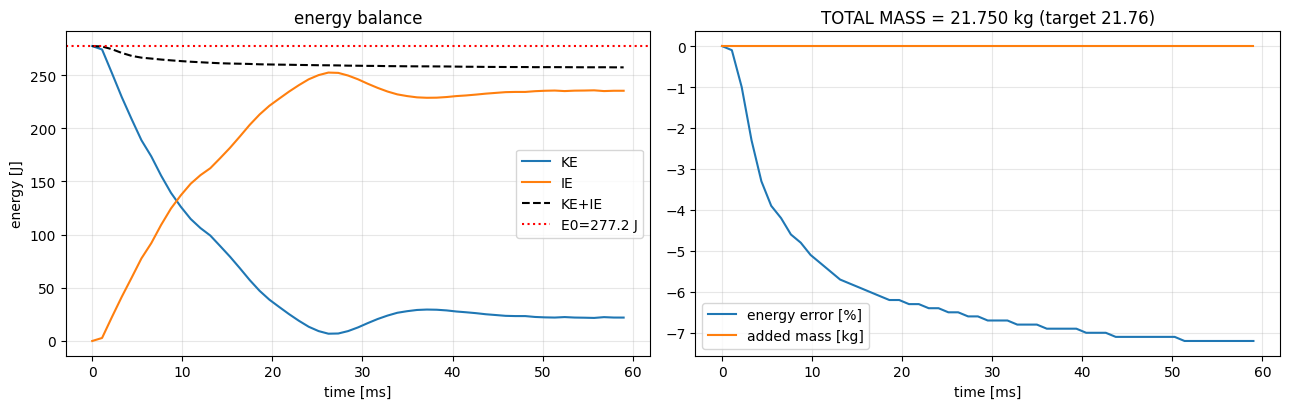

  KE 277.2->22.0 J | IE 0->235.2 J | sum 257.2/277.2 (-7.2 %)
  err -7.2 %  added mass 0 kg (0.00 %)
  !! energy error above 5 % -> suspect contact penetration / hourglass
  !! falling back to the ANIM signal (lower accuracy)
  signal source: ANIM/vel (1st deriv., coarse)   samples=99
  !! dt=2.5e-04 s is too coarse for CFC1000 -> unfiltered
  !! the head is still loaded at T_END -> increase CFG['T_END']; HIC may be underestimated


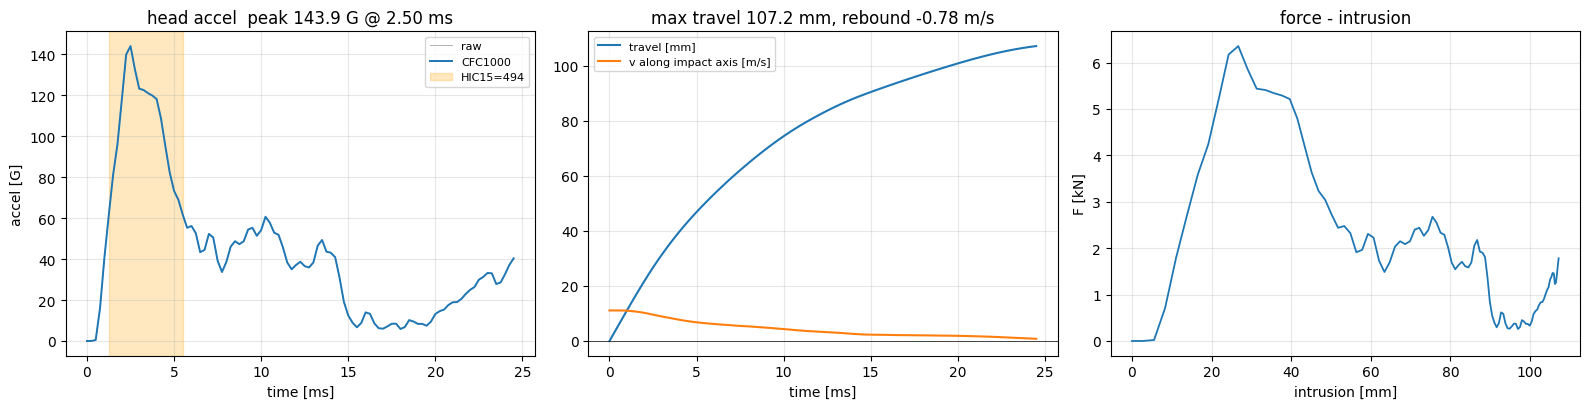


  job: head_impact
  units: ton-mm-s
  angle_deg: 65.0
  E0_J: 277.2225000000001
  hardpoint_mm: 0.0
  elform: 16
  spc_mode: hinge_latch
  T_END_ms: 60.0
  KE_end_J: 21.9979
  IE_end_J: 235.20000000000002
  E_sum_end_J: 257.1979
  E_balance_pct: -7.223295367439533
  energy_err_pct: -7.2
  total_mass_kg: 21.749999999999996
  added_mass_kg: 0.0
  added_mass_frac: 0.0
  signal_src: ANIM/vel (1st deriv., coarse)
  dt_s: 0.0002500000000000002
  cfc: 1000.0
  peak_g: 143.9391947320452
  t_peak_ms: 2.5
  HIC15: 493.8420556754118
  HIC_window_ms: [1.25, 5.5]
  HIC36: 493.8420556754118
  tail_accel_g: 36.646372301027874
  contact_truncated: True
  second_peak_g: 60.63029988400793
  travel_mm: 107.2265112099432
  v_rebound_ms: -0.7808100051230404
  head_KE_end_J: 1.3717445942255455


In [5]:
# =============================================================================
#  CELL 5 : post-processing (energy balance, CFC1000 head signal, HIC)
#  Signal priority : TH acceleration > TH velocity (1st deriv.)
#                  > TH displacement (2nd deriv.) > ANIM velocity > ANIM disp.
# =============================================================================
import os, re, glob, json, math, subprocess
import numpy as np, matplotlib.pyplot as plt

S = json.load(open("/content/state.json"))
META = json.load(open(S["DECKD"] + "/meta.json"))
RUN, JOB, U, OUTD, CFG = S["RUN"], S["JOB"], META["U"], S["OUTD"], S["CFG"]
ACC2G, E2J, T_END, ADT = META["ACC2G"], META["E2J"], META["T_END"], META["ADT"]
NUM = r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[EeDd][-+]?\d+)?"
print("=" * 66 + "\n  CELL 5  post\n" + "=" * 66)

res = dict(job=JOB, units=U["n"], angle_deg=CFG["ANGLE_DEG"], E0_J=META["E0_J"],
           hardpoint_mm=CFG["HARDPOINT"], elform=CFG["ELFORM"],
           spc_mode=CFG["SPC_MODE"], T_END_ms=CFG["T_END"] * 1e3)

# --------------------------------------------------------------------------
#  1) energy balance : column layout is auto-detected by matching KE(0) to E0
# --------------------------------------------------------------------------
raw = [[float(x.rstrip("%").replace("D", "E")) for x in l.split()
        if re.fullmatch(NUM + "%?", x)]
       for l in open(f"{RUN}/{JOB}_0001.out", errors="ignore")]
LAY = {"A": dict(err=-8, ie=-7, ket=-6, ker=-5, tm=-2, am=-1),   # with TOTAL MASS
       "B": dict(err=-6, ie=-5, ket=-4, ker=-3, tm=None, am=-1)}  # without
best, E, lay = None, None, None
for nc in (13, 12, 11, 10):
    rows = [v for v in raw if len(v) == nc and 0.0 <= v[1] <= T_END * 1.01]
    if len(rows) < 5:
        continue
    M = np.array(rows)
    for tag, ix in LAY.items():
        if abs(ix["err"]) > nc:
            continue
        ke0 = (M[0, ix["ket"]] + M[0, ix["ker"]]) * E2J
        sc = abs(ke0 / META["E0_J"] - 1.0)
        if best is None or sc < best:
            best, E, lay = sc, M, ix
assert E is not None, "no energy rows found in the engine .out"
print(f"  energy rows = {len(E)}  layout match = {100*best:.1f} % off E0")
tms = E[:, 1] / U["T"] * 1e3
err = E[:, lay["err"]]
IE  = E[:, lay["ie"]] * E2J
KE  = (E[:, lay["ket"]] + E[:, lay["ker"]]) * E2J
TM  = E[:, lay["tm"]] / U["M"] if lay["tm"] else np.full(len(E), np.nan)
MA  = E[:, lay["am"]] / U["M"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(tms, KE, label="KE"); ax[0].plot(tms, IE, label="IE")
ax[0].plot(tms, KE + IE, "k--", label="KE+IE")
ax[0].axhline(META["E0_J"], color="r", ls=":", label=f"E0={META['E0_J']:.1f} J")
ax[0].set(xlabel="time [ms]", ylabel="energy [J]", title="energy balance")
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(tms, err, label="energy error [%]")
ax[1].plot(tms, MA, label="added mass [kg]")
ax[1].set(xlabel="time [ms]",
          title=f"TOTAL MASS = {TM[-1]:.3f} kg (target {META['total_kg']:.2f})")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUTD + "/energy.png", dpi=130); plt.show()
np.savetxt(OUTD + "/energy.csv", np.c_[tms, KE, IE, err, MA], delimiter=",",
           header="time_ms,KE_J,IE_J,err_pct,added_mass_kg", comments="")

am_frac = float(MA[-1] / META["total_kg"])
res.update(KE_end_J=float(KE[-1]), IE_end_J=float(IE[-1]),
           E_sum_end_J=float(KE[-1] + IE[-1]),
           E_balance_pct=float(100 * (KE[-1] + IE[-1]) / META["E0_J"] - 100),
           energy_err_pct=float(err[-1]), total_mass_kg=float(TM[-1]),
           added_mass_kg=float(MA[-1]), added_mass_frac=am_frac)
print(f"  KE {KE[0]:.1f}->{KE[-1]:.1f} J | IE 0->{IE[-1]:.1f} J | "
      f"sum {KE[-1]+IE[-1]:.1f}/{META['E0_J']:.1f} ({res['E_balance_pct']:+.1f} %)")
print(f"  err {err[-1]:+.1f} %  added mass {MA[-1]:.4g} kg ({100*am_frac:.2f} %)")
if abs(err[-1]) > 5:
    print("  !! energy error above 5 % -> suspect contact penetration / hourglass")
if am_frac > CFG["MASS_SCALE_MAX"]:
    print(f"  !! added mass above {100*CFG['MASS_SCALE_MAX']:.0f} % -> "
          "reduce the /DT/NODA/CST target")

# --------------------------------------------------------------------------
#  2) head signal
# --------------------------------------------------------------------------
def cfc_filter(y, dt, cfc):
    """SAE J211 4-pole Butterworth, applied forward and backward (zero phase)."""
    wd = 2 * math.pi * cfc * 2.0775
    wa = math.tan(wd * dt / 2.0)
    den = 1 + math.sqrt(2) * wa + wa ** 2
    a0 = wa ** 2 / den; a1 = 2 * a0; a2 = a0
    b1 = -2 * (wa ** 2 - 1) / den
    b2 = (-1 + math.sqrt(2) * wa - wa ** 2) / den
    def pass1(x):
        o = np.zeros_like(x)
        o[0] = x[0]; o[1] = x[1]
        for i in range(2, len(x)):
            o[i] = a0 * x[i] + a1 * x[i-1] + a2 * x[i-2] + b1 * o[i-1] + b2 * o[i-2]
        return o
    pad = np.r_[np.full(50, y[0]), y, np.full(50, y[-1])]
    return pass1(pass1(pad)[::-1])[::-1][50:-50]

def read_csv_tolerant(path):
    hdr, rows = None, []
    for line in open(path, errors="ignore"):
        p = [x.strip() for x in line.replace(";", ",").split(",")]
        if len(p) < 2:
            continue
        try:
            rows.append([float(x.replace("D", "E")) for x in p])
        except ValueError:
            if any(re.search(r"[A-Za-z]", x) for x in p) and not rows:
                hdr = p
    return hdr, (np.array(rows) if rows else None)

def th_signal():
    """Return (t[s], acc_vec[len,3] in model units) from the OpenRadioss T-files."""
    if not S.get("T2C"):
        return None
    tf = sorted(glob.glob(f"{RUN}/{JOB}T0*"))
    if not tf:
        return None
    for f in tf:
        subprocess.run([S["T2C"], os.path.basename(f)], cwd=RUN,
                       capture_output=True, text=True)
    best = None
    for c in sorted(glob.glob(f"{RUN}/*.csv")):
        hdr, M = read_csv_tolerant(c)
        if M is None or hdr is None or M.shape[0] < 50:
            continue
        H = [h.upper() for h in hdr][:M.shape[1]]
        cn = str(META["CN"])
        def col(pats, need_cn=True):
            for i, h in enumerate(H):
                if need_cn and cn not in h:
                    continue
                if all(p in h for p in pats):
                    return i
            return None
        for kind, keys in (("acc", (["A", "X"], ["A", "Z"])),
                           ("vel", (["V", "X"], ["V", "Z"])),
                           ("dis", (["D", "X"], ["D", "Z"]))):
            ix = [col(k) for k in keys]
            if all(v is not None for v in ix):
                t = M[:, 0] / U["T"]
                sig = np.c_[M[:, ix[0]], np.zeros(len(M)), M[:, ix[1]]]
                best = (kind, t, sig, os.path.basename(c))
                break
        if best:
            break
    if not best:
        return None
    kind, t, sig, name = best
    dt = float(np.median(np.diff(t)))
    if kind == "dis":
        sig = np.gradient(np.gradient(sig, t, axis=0), t, axis=0)
    elif kind == "vel":
        sig = np.gradient(sig, t, axis=0)
    return t, sig, f"TH/{kind} ({name}, dt={dt:.1e} s)"

def read_vtk(path):
    """Minimal legacy-ASCII VTK reader for anim_to_vtk output."""
    w = open(path, errors="ignore").read().split()
    out = {"scal": {}, "vec": {}}
    i = w.index("POINTS"); n = int(w[i + 1])
    out["pts"] = np.array(w[i + 3:i + 3 + 3 * n], float).reshape(n, 3)
    if "CELLS" in w:
        i = w.index("CELLS"); nc, sz = int(w[i + 1]), int(w[i + 2])
        flat = np.array(w[i + 3:i + 3 + sz], int); cells, k = [], 0
        while k < sz:
            m = flat[k]; cells.append(flat[k + 1:k + 1 + m]); k += m + 1
        out["cells"] = cells
    for k, tok in enumerate(w):
        if tok == "SCALARS":
            name = w[k + 1]
            j = k + 2
            while j < len(w) and w[j] != "default":
                j += 1
            j += 1
            m = len(out["pts"]) if "cells" not in out else None
            m = m or (len(out["pts"]) if name.lower().startswith("d") else len(out["cells"]))
            try:
                out["scal"][name] = np.array(w[j:j + m], float)
            except ValueError:
                pass
        elif tok == "VECTORS":
            name = w[k + 1]
            try:
                out["vec"][name] = np.array(
                    w[k + 3:k + 3 + 3 * len(out["pts"])], float).reshape(-1, 3)
            except ValueError:
                pass
    return out

def anim_signal():
    """Fallback: differentiate the ANIM velocity field of the headform nodes."""
    A = sorted(glob.glob(f"{RUN}/{JOB}A0*"))
    if not (S.get("A2V") and A):
        return None
    ctr, R = np.array(META["ctr"]), META["head_R"]
    frames, hm = [], None
    for af in A:
        with open("/content/_a.vtk", "w") as o:
            subprocess.run([S["A2V"], os.path.basename(af)], cwd=RUN,
                           stdout=o, stderr=subprocess.DEVNULL)
        d = read_vtk("/content/_a.vtk")
        if hm is None:
            hm = np.abs(np.linalg.norm(d["pts"] - ctr, axis=1) - R) < 0.06 * R
            assert hm.sum() > 200, "headform node detection by geometry failed"
        v = next((a for k, a in d["vec"].items() if "vel" in k.lower()), None)
        frames.append((d["pts"][hm].mean(0), None if v is None else v[hm].mean(0)))
    t = np.arange(len(frames)) * ADT / U["T"]
    if frames[0][1] is not None:
        V = np.array([f[1] for f in frames])
        return t, np.gradient(V, t, axis=0), "ANIM/vel (1st deriv., coarse)"
    P = np.array([f[0] for f in frames])
    return t, np.gradient(np.gradient(P, t, axis=0), t, axis=0), \
           "ANIM/disp (2nd deriv., low accuracy)"

sig = None
try:
    sig = th_signal()
except Exception as e:
    print(f"  TH reading failed: {e}")
if sig is None:
    print("  !! falling back to the ANIM signal (lower accuracy)")
    sig = anim_signal()
assert sig is not None, "no head signal source available"
t, acc, srcname = sig
print(f"  signal source: {srcname}   samples={len(t)}")

dt = float(np.median(np.diff(t)))
a_raw = np.linalg.norm(acc, axis=1) * ACC2G                # resultant, [G]
a_g = cfc_filter(a_raw, dt, CFG["CFC"]) if dt < 1 / (10 * CFG["CFC"]) else a_raw
if dt >= 1 / (10 * CFG["CFC"]):
    print(f"  !! dt={dt:.1e} s is too coarse for CFC{CFG['CFC']:.0f} -> unfiltered")

# integrate the filtered acceleration for velocity / travel along the impact axis
vhat = np.array(META["vhat"])
a_ax = (acc @ vhat) * ACC2G * 9.81                          # [m/s^2]
v_ax = CFG["V_IMPACT"] + np.concatenate(
    [[0], np.cumsum(np.diff(t) * (a_ax[1:] + a_ax[:-1]) / 2)])
path = np.concatenate([[0], np.cumsum(np.diff(t) * (v_ax[1:] + v_ax[:-1]) / 2)]) * 1e3

def hic(t, a, win):
    V = np.concatenate([[0], np.cumsum(np.diff(t) * (a[1:] + a[:-1]) / 2)])
    best = (0.0, 0.0, 0.0)
    for i in range(len(t) - 1):
        k = np.arange(i + 1, min(np.searchsorted(t, t[i] + win) + 1, len(t)))
        if not k.size:
            continue
        T = t[k] - t[i]
        v = ((V[k] - V[i]) / T) ** 2.5 * T
        j = int(v.argmax())
        if v[j] > best[0]:
            best = (float(v[j]), float(t[i]), float(t[k[j]]))
    return best

H15, t1, t2 = hic(t, a_g, CFG["HIC_WIN"])
H36, *_     = hic(t, a_g, 0.036)
ipk = int(a_g.argmax())
tail = float(np.mean(a_g[-max(3, len(a_g) // 50):]))
truncated = tail > 0.05 * a_g.max() or t2 > t[-1] - 2 * dt
res.update(signal_src=srcname, dt_s=dt, cfc=CFG["CFC"],
           peak_g=float(a_g.max()), t_peak_ms=float(t[ipk] * 1e3),
           HIC15=float(H15), HIC_window_ms=[t1 * 1e3, t2 * 1e3],
           HIC36=float(H36), tail_accel_g=tail, contact_truncated=bool(truncated),
           second_peak_g=float(a_g[t > 8e-3].max()) if (t > 8e-3).any() else None,
           travel_mm=float(path.max()),
           v_rebound_ms=float(-v_ax[-1]),
           head_KE_end_J=float(0.5 * CFG["HEAD_MASS"] * v_ax[-1] ** 2))
if truncated:
    print("  !! the head is still loaded at T_END -> increase CFG['T_END']; "
          "HIC may be underestimated")

Fk = CFG["HEAD_MASS"] * a_g * 9.81 / 1e3     # exact for a rigid body (F = m a)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(t * 1e3, a_raw, lw=.7, c="0.7", label="raw")
ax[0].plot(t * 1e3, a_g, lw=1.4, label=f"CFC{CFG['CFC']:.0f}")
ax[0].axvspan(t1 * 1e3, t2 * 1e3, color="orange", alpha=.25, label=f"HIC15={H15:.0f}")
ax[0].set(xlabel="time [ms]", ylabel="accel [G]",
          title=f"head accel  peak {a_g.max():.1f} G @ {res['t_peak_ms']:.2f} ms")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(t * 1e3, path, label="travel [mm]")
ax[1].plot(t * 1e3, v_ax, label="v along impact axis [m/s]")
ax[1].axhline(0, c="k", lw=.5)
ax[1].set(xlabel="time [ms]", title=f"max travel {path.max():.1f} mm, "
          f"rebound {res['v_rebound_ms']:.2f} m/s")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
ax[2].plot(path, Fk, lw=1.3)
ax[2].set(xlabel="intrusion [mm]", ylabel="F [kN]", title="force - intrusion")
ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUTD + "/result.png", dpi=130); plt.show()

np.savetxt(OUTD + "/head_accel.csv",
           np.c_[t * 1e3, a_raw, a_g, path, v_ax, Fk], delimiter=",",
           header="time_ms,accel_raw_G,accel_CFC_G,travel_mm,vel_ms,force_kN",
           comments="")
json.dump(res, open(OUTD + "/summary.json", "w"), indent=1)
print()
for k, v in res.items():
    print(f"  {k}: {v}")


res.update(spc_sets=META.get("spc_sets"), hem_ties=META.get("hem_ties"),
           mastic_ties=META.get("mastic_ties"),
           support_clearance_mm=META.get("support_clearance_mm"))


In [3]:
# ============================================================================
# CELL 6
# Final-time design-oriented 2D contour visualization
# ============================================================================

import os
import csv
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import BoundaryNorm
from matplotlib.collections import PolyCollection


# ----------------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------------

OUTPUT_DIR = globals().get(
    "OUTPUT_DIR",
    "/content/drive/MyDrive/head_impact_radioss",
)

CONTOUR_LEVEL_COUNT = 20
COLORMAP_NAME = "jet"
COLOR_PERCENTILE = 99.5

FIGURE_WIDTH = 19
FIGURE_HEIGHT = 15
FIGURE_DPI = 180

DISPLACEMENT_UNIT = "model unit"
STRESS_UNIT = "model unit"

OUTPUT_IMAGE_NAME = "final_time_design_review_2d.png"
OUTPUT_CSV_NAME = "design_review_summary.csv"
OUTPUT_GUIDANCE_NAME = "design_review_guidance.txt"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ----------------------------------------------------------------------------
# Validation
# ----------------------------------------------------------------------------

if "FRAME_DATA" not in globals():
    raise RuntimeError(
        "FRAME_DATA was not found. Run the animation-data loading cell first."
    )

if not isinstance(FRAME_DATA, (list, tuple)):
    raise TypeError("FRAME_DATA must be a list or tuple.")

if len(FRAME_DATA) == 0:
    raise RuntimeError("FRAME_DATA is empty.")


# ----------------------------------------------------------------------------
# Field utilities
# ----------------------------------------------------------------------------

def normalize_name(value):
    return (
        str(value)
        .lower()
        .replace(" ", "")
        .replace("_", "")
        .replace("-", "")
    )


def find_field(container, names):
    if not isinstance(container, dict):
        return None, None

    key_map = {
        normalize_name(key): key
        for key in container.keys()
    }

    for name in names:
        normalized_name = normalize_name(name)

        if normalized_name in key_map:
            key = key_map[normalized_name]
            return container[key], key

    nested_names = [
        "scalars",
        "scalar",
        "vectors",
        "vector",
        "fields",
        "field_data",
        "data",
    ]

    for nested_name in nested_names:
        nested = None

        for key, value in container.items():
            if normalize_name(key) == normalize_name(nested_name):
                nested = value
                break

        if isinstance(nested, dict):
            value, key = find_field(nested, names)

            if value is not None:
                return value, key

    return None, None


def required_field(frame, names, description):
    value, matched_name = find_field(frame, names)

    if value is None:
        raise KeyError(
            f"Missing {description}. "
            f"Candidates: {names}"
        )

    return value, matched_name


def optional_field(frame, names):
    return find_field(frame, names)


def scalarize(values):
    values = np.asarray(values, dtype=float)
    values = np.squeeze(values)

    if values.ndim == 1:
        return values

    if values.ndim == 2 and values.shape[1] == 1:
        return values[:, 0]

    if values.ndim == 2 and values.shape[1] >= 3:
        return np.linalg.norm(values[:, :3], axis=1)

    raise ValueError(
        f"Unsupported field shape: {values.shape}"
    )


def convert_points(raw_points):
    points = np.asarray(raw_points, dtype=float)

    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(
            f"Points must have shape (N, 3), got {points.shape}"
        )

    return points


def convert_cells(raw_cells):
    """
    Preserve original cell indexing.
    Invalid cells are retained as empty arrays.
    """
    cells = []

    for raw_cell in raw_cells:
        try:
            cell = np.asarray(raw_cell, dtype=int).reshape(-1)
        except Exception:
            cell = np.asarray([], dtype=int)

        cells.append(cell)

    if len(cells) == 0:
        raise RuntimeError("No cells were found.")

    return cells


def make_cell_values(points, cells, raw_values, field_name):
    """
    Convert nodal or element data into values indexed by original cells.
    """
    values = scalarize(raw_values)

    if len(values) == len(points):
        result = np.full(len(cells), np.nan, dtype=float)

        for cell_index, cell in enumerate(cells):
            valid = cell[
                (cell >= 0) &
                (cell < len(values))
            ]

            if len(valid) == 0:
                continue

            node_values = values[valid]
            node_values = node_values[
                np.isfinite(node_values)
            ]

            if len(node_values) > 0:
                result[cell_index] = np.nanmean(node_values)

        return result

    if len(values) == len(cells):
        return values.astype(float)

    print(
        f"Warning: {field_name} length mismatch. "
        f"Field values={len(values)}, cells={len(cells)}"
    )

    result = np.full(len(cells), np.nan, dtype=float)
    copy_count = min(len(values), len(cells))
    result[:copy_count] = values[:copy_count]

    return result


def make_cell_labels(points, cells, raw_values):
    """
    Convert nodal or element labels into one label per cell.
    """
    if raw_values is None:
        return np.full(len(cells), "Unavailable", dtype=object)

    values = np.asarray(raw_values).reshape(-1)

    if len(values) == len(cells):
        return values.astype(object)

    if len(values) == len(points):
        result = np.full(len(cells), "Unavailable", dtype=object)

        for cell_index, cell in enumerate(cells):
            valid = cell[
                (cell >= 0) &
                (cell < len(values))
            ]

            if len(valid) == 0:
                continue

            result[cell_index] = values[valid[0]]

        return result

    return np.full(len(cells), "Unavailable", dtype=object)


def get_limits(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return 0.0, 1.0

    value_min = float(np.nanmin(values))
    value_max = float(np.nanpercentile(values, COLOR_PERCENTILE))

    value_min = min(0.0, value_min)

    if not np.isfinite(value_max):
        value_max = 1.0

    if value_max <= value_min:
        value_max = value_min + 1.0

    return value_min, value_max


def finite_max_index(values):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    if not np.any(valid):
        return None

    safe_values = np.where(valid, values, -np.inf)
    return int(np.argmax(safe_values))


def format_number(value):
    if value is None:
        return "Unavailable"

    if not np.isfinite(value):
        return "Unavailable"

    return f"{float(value):.6g}"


# ----------------------------------------------------------------------------
# 2D geometry and drawing
# ----------------------------------------------------------------------------

def projection_indices(projection):
    if projection == "top":
        return (0, 1), "X", "Y"

    if projection == "side":
        return (0, 2), "X", "Z"

    raise ValueError(f"Unknown projection: {projection}")


def draw_2d_field(
    axis,
    points,
    cells,
    values,
    projection,
    value_min,
    value_max,
    maximum_cell_index,
):
    coordinate_indices, horizontal_label, vertical_label = (
        projection_indices(projection)
    )

    polygons = []
    polygon_values = []
    polygon_cell_indices = []

    for cell_index, cell in enumerate(cells):
        if len(cell) < 3:
            continue

        if cell_index >= len(values):
            continue

        value = values[cell_index]

        if not np.isfinite(value):
            continue

        valid = cell[
            (cell >= 0) &
            (cell < len(points))
        ]

        if len(valid) < 3:
            continue

        polygon_3d = points[valid]
        polygon_2d = polygon_3d[:, coordinate_indices]

        if polygon_2d.ndim != 2:
            continue

        if polygon_2d.shape[1] != 2:
            continue

        polygons.append(polygon_2d)
        polygon_values.append(value)
        polygon_cell_indices.append(cell_index)

    if len(polygons) == 0:
        return None

    polygon_values = np.asarray(
        polygon_values,
        dtype=float,
    )

    if value_max <= value_min:
        normalized = np.zeros(len(polygon_values))
    else:
        normalized = (
            (polygon_values - value_min) /
            (value_max - value_min)
        )
        normalized = np.clip(normalized, 0.0, 1.0)

    color_indices = np.floor(
        normalized * CONTOUR_LEVEL_COUNT
    ).astype(int)

    color_indices = np.clip(
        color_indices,
        0,
        CONTOUR_LEVEL_COUNT - 1,
    )

    colormap = plt.get_cmap(
        COLORMAP_NAME,
        CONTOUR_LEVEL_COUNT,
    )

    colors = colormap(color_indices)

    collection = PolyCollection(
        polygons,
        facecolors=colors,
        edgecolors="none",
        linewidths=0.0,
        antialiaseds=False,
    )

    axis.add_collection(collection)

    all_points_2d = np.concatenate(
        polygons,
        axis=0,
    )

    x_min = float(np.nanmin(all_points_2d[:, 0]))
    x_max = float(np.nanmax(all_points_2d[:, 0]))
    y_min = float(np.nanmin(all_points_2d[:, 1]))
    y_max = float(np.nanmax(all_points_2d[:, 1]))

    x_range = max(x_max - x_min, 1.0)
    y_range = max(y_max - y_min, 1.0)

    x_padding = 0.04 * x_range
    y_padding = 0.04 * y_range

    axis.set_xlim(
        x_min - x_padding,
        x_max + x_padding,
    )

    axis.set_ylim(
        y_min - y_padding,
        y_max + y_padding,
    )

    axis.set_aspect(
        "equal",
        adjustable="box",
    )

    if maximum_cell_index in polygon_cell_indices:
        local_index = polygon_cell_indices.index(
            maximum_cell_index
        )

        maximum_polygon = polygons[local_index]
        maximum_center = np.nanmean(
            maximum_polygon,
            axis=0,
        )

        axis.scatter(
            maximum_center[0],
            maximum_center[1],
            s=130,
            c="white",
            edgecolors="black",
            linewidths=2.0,
            marker="*",
            zorder=10,
        )

        axis.annotate(
            "MAX",
            xy=(
                maximum_center[0],
                maximum_center[1],
            ),
            xytext=(12, 12),
            textcoords="offset points",
            fontsize=13,
            fontweight="bold",
            color="black",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "black",
                "alpha": 0.9,
            },
            arrowprops={
                "arrowstyle": "->",
                "color": "black",
                "linewidth": 1.5,
            },
        )

    return {
        "horizontal_label": horizontal_label,
        "vertical_label": vertical_label,
    }


def add_colorbar(
    figure,
    axis,
    value_min,
    value_max,
    label,
):
    boundaries = np.linspace(
        value_min,
        value_max,
        CONTOUR_LEVEL_COUNT + 1,
    )

    colormap = plt.get_cmap(
        COLORMAP_NAME,
        CONTOUR_LEVEL_COUNT,
    )

    norm = BoundaryNorm(
        boundaries,
        CONTOUR_LEVEL_COUNT,
    )

    mapper = plt.cm.ScalarMappable(
        norm=norm,
        cmap=colormap,
    )

    mapper.set_array([])

    colorbar = figure.colorbar(
        mapper,
        ax=axis,
        shrink=0.78,
        pad=0.03,
    )

    colorbar.set_label(
        label,
        fontsize=13,
    )

    colorbar.ax.tick_params(
        labelsize=10,
    )


# ----------------------------------------------------------------------------
# Read final frame
# ----------------------------------------------------------------------------

final_frame_index = len(FRAME_DATA) - 1
final_frame = FRAME_DATA[final_frame_index]

raw_points, points_name = required_field(
    final_frame,
    [
        "points",
        "pts",
        "coordinates",
        "nodes",
    ],
    "point coordinates",
)

raw_cells, cells_name = required_field(
    final_frame,
    [
        "cells",
        "elements",
        "connectivity",
        "polygons",
    ],
    "cell connectivity",
)

raw_displacement, displacement_name = required_field(
    final_frame,
    [
        "displacement",
        "disp",
        "displacement_magnitude",
        "displacement_vector",
    ],
    "displacement",
)

raw_von_mises, von_mises_name = required_field(
    final_frame,
    [
        "2DELEM_Von_Mises",
        "1DELEM_Von_Mises",
        "von_mises",
        "vonm",
        "von_mises_stress",
        "stress",
    ],
    "von Mises stress",
)

raw_part_id, part_id_name = optional_field(
    final_frame,
    [
        "PART_ID",
        "part_id",
        "partid",
        "part",
    ],
)

points = convert_points(raw_points)
cells = convert_cells(raw_cells)

displacement_values = make_cell_values(
    points,
    cells,
    raw_displacement,
    "displacement",
)

von_mises_values = make_cell_values(
    points,
    cells,
    raw_von_mises,
    "von Mises stress",
)

part_ids = make_cell_labels(
    points,
    cells,
    raw_part_id,
)

displacement_min, displacement_max = get_limits(
    displacement_values
)

von_mises_min, von_mises_max = get_limits(
    von_mises_values
)

maximum_displacement_cell = finite_max_index(
    displacement_values
)

maximum_stress_cell = finite_max_index(
    von_mises_values
)


# ----------------------------------------------------------------------------
# Maximum locations
# ----------------------------------------------------------------------------

def cell_center(points, cells, cell_index):
    if cell_index is None:
        return np.full(3, np.nan)

    if cell_index >= len(cells):
        return np.full(3, np.nan)

    cell = cells[cell_index]

    valid = cell[
        (cell >= 0) &
        (cell < len(points))
    ]

    if len(valid) == 0:
        return np.full(3, np.nan)

    return np.nanmean(
        points[valid],
        axis=0,
    )


maximum_displacement_location = cell_center(
    points,
    cells,
    maximum_displacement_cell,
)

maximum_stress_location = cell_center(
    points,
    cells,
    maximum_stress_cell,
)

maximum_displacement_value = (
    None
    if maximum_displacement_cell is None
    else displacement_values[maximum_displacement_cell]
)

maximum_stress_value = (
    None
    if maximum_stress_cell is None
    else von_mises_values[maximum_stress_cell]
)

maximum_displacement_part = (
    "Unavailable"
    if maximum_displacement_cell is None
    else str(part_ids[maximum_displacement_cell])
)

maximum_stress_part = (
    "Unavailable"
    if maximum_stress_cell is None
    else str(part_ids[maximum_stress_cell])
)


# ----------------------------------------------------------------------------
# Create figure
# ----------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

figure, axes = plt.subplots(
    2,
    2,
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
    dpi=FIGURE_DPI,
    constrained_layout=True,
)

plot_items = [
    (
        axes[0, 0],
        displacement_values,
        displacement_min,
        displacement_max,
        "Displacement - Top view",
        f"Displacement [{DISPLACEMENT_UNIT}]",
        "top",
        maximum_displacement_cell,
        "X",
        "Y",
    ),
    (
        axes[0, 1],
        displacement_values,
        displacement_min,
        displacement_max,
        "Displacement - Side view",
        f"Displacement [{DISPLACEMENT_UNIT}]",
        "side",
        maximum_displacement_cell,
        "X",
        "Z",
    ),
    (
        axes[1, 0],
        von_mises_values,
        von_mises_min,
        von_mises_max,
        "von Mises stress - Top view",
        f"von Mises stress [{STRESS_UNIT}]",
        "top",
        maximum_stress_cell,
        "X",
        "Y",
    ),
    (
        axes[1, 1],
        von_mises_values,
        von_mises_min,
        von_mises_max,
        "von Mises stress - Side view",
        f"von Mises stress [{STRESS_UNIT}]",
        "side",
        maximum_stress_cell,
        "X",
        "Z",
    ),
]

for item in plot_items:
    axis = item[0]
    values = item[1]
    value_min = item[2]
    value_max = item[3]
    title = item[4]
    colorbar_label = item[5]
    projection = item[6]
    maximum_cell_index = item[7]
    horizontal_label = item[8]
    vertical_label = item[9]

    draw_2d_field(
        axis=axis,
        points=points,
        cells=cells,
        values=values,
        projection=projection,
        value_min=value_min,
        value_max=value_max,
        maximum_cell_index=maximum_cell_index,
    )

    axis.set_title(
        title,
        fontsize=18,
        fontweight="bold",
    )

    axis.set_xlabel(
        horizontal_label,
        fontsize=14,
    )

    axis.set_ylabel(
        vertical_label,
        fontsize=14,
    )

    axis.grid(
        True,
        linewidth=0.5,
        alpha=0.35,
    )

    add_colorbar(
        figure=figure,
        axis=axis,
        value_min=value_min,
        value_max=value_max,
        label=colorbar_label,
    )


figure.suptitle(
    "Final-Time Head-Impact Design Review",
    fontsize=24,
    fontweight="bold",
)


# ----------------------------------------------------------------------------
# Save image
# ----------------------------------------------------------------------------

image_path = os.path.join(
    OUTPUT_DIR,
    OUTPUT_IMAGE_NAME,
)

figure.savefig(
    image_path,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Save CSV summary
# ----------------------------------------------------------------------------

csv_path = os.path.join(
    OUTPUT_DIR,
    OUTPUT_CSV_NAME,
)

with open(
    csv_path,
    "w",
    newline="",
    encoding="utf-8",
) as file:
    writer = csv.writer(file)

    writer.writerow([
        "quantity",
        "value",
        "unit",
        "cell_index",
        "part_id",
        "x",
        "y",
        "z",
    ])

    writer.writerow([
        "maximum_displacement",
        format_number(maximum_displacement_value),
        DISPLACEMENT_UNIT,
        maximum_displacement_cell,
        maximum_displacement_part,
        format_number(maximum_displacement_location[0]),
        format_number(maximum_displacement_location[1]),
        format_number(maximum_displacement_location[2]),
    ])

    writer.writerow([
        "maximum_von_mises_stress",
        format_number(maximum_stress_value),
        STRESS_UNIT,
        maximum_stress_cell,
        maximum_stress_part,
        format_number(maximum_stress_location[0]),
        format_number(maximum_stress_location[1]),
        format_number(maximum_stress_location[2]),
    ])


# ----------------------------------------------------------------------------
# Save design guidance
# ----------------------------------------------------------------------------

guidance_path = os.path.join(
    OUTPUT_DIR,
    OUTPUT_GUIDANCE_NAME,
)

with open(
    guidance_path,
    "w",
    encoding="utf-8",
) as file:
    file.write(
        "FINAL-TIME HEAD-IMPACT DESIGN REVIEW\n"
        "=====================================\n\n"
    )

    file.write(
        "Purpose\n"
        "-------\n"
        "Use this result to identify the region that should be reviewed "
        "before the next design iteration.\n\n"
    )

    file.write(
        "Visualization settings\n"
        "----------------------\n"
        f"Frame index: {final_frame_index}\n"
        "Projection: top XY and side XZ\n"
        "Aspect ratio: equal\n"
        f"Contour levels: {CONTOUR_LEVEL_COUNT}\n"
        f"Colormap: {COLORMAP_NAME}\n\n"
    )

    file.write(
        "Maximum displacement\n"
        "--------------------\n"
        f"Value: {format_number(maximum_displacement_value)} "
        f"{DISPLACEMENT_UNIT}\n"
        f"Cell index: {maximum_displacement_cell}\n"
        f"Part ID: {maximum_displacement_part}\n"
        f"Location X: {format_number(maximum_displacement_location[0])}\n"
        f"Location Y: {format_number(maximum_displacement_location[1])}\n"
        f"Location Z: {format_number(maximum_displacement_location[2])}\n\n"
    )

    file.write(
        "Maximum von Mises stress\n"
        "------------------------\n"
        f"Value: {format_number(maximum_stress_value)} "
        f"{STRESS_UNIT}\n"
        f"Cell index: {maximum_stress_cell}\n"
        f"Part ID: {maximum_stress_part}\n"
        f"Location X: {format_number(maximum_stress_location[0])}\n"
        f"Location Y: {format_number(maximum_stress_location[1])}\n"
        f"Location Z: {format_number(maximum_stress_location[2])}\n\n"
    )

    file.write(
        "Recommended design review sequence\n"
        "----------------------------------\n"
        "1. Inspect the marked maximum displacement region.\n"
        "2. Inspect the marked maximum stress region.\n"
        "3. Confirm whether the marked regions belong to the structural "
        "part or the contact/headform region.\n"
        "4. Compare the maximum stress with the applicable material or "
        "design allowable.\n"
        "5. Review the corresponding Part ID before changing geometry.\n"
        "6. If the allowable is exceeded, review thickness, curvature, "
        "support conditions, and local reinforcement.\n"
        "7. Repeat the analysis after the design change.\n\n"
    )

    file.write(
        "Important limitation\n"
        "--------------------\n"
        "The displacement and stress units are reported as model units "
        "unless the model unit system has been verified separately.\n"
    )


# ----------------------------------------------------------------------------
# Completion report
# ----------------------------------------------------------------------------

print("=" * 70)
print("Final-time design-oriented visualization completed")
print("=" * 70)
print(f"Final frame index: {final_frame_index}")
print("Projection: top XY and side XZ")
print("Aspect ratio: equal")
print("Contour levels: 20")
print("Colormap: jet")
print("GIF generation: disabled")
print(f"Displacement field: {displacement_name}")
print(f"von Mises field: {von_mises_name}")
print(f"Part field: {part_id_name}")
print(
    f"Maximum displacement: "
    f"{format_number(maximum_displacement_value)} "
    f"{DISPLACEMENT_UNIT}"
)
print(f"Maximum displacement part: {maximum_displacement_part}")
print(
    f"Maximum von Mises stress: "
    f"{format_number(maximum_stress_value)} "
    f"{STRESS_UNIT}"
)
print(f"Maximum stress part: {maximum_stress_part}")
print(f"Saved image: {image_path}")
print(f"Saved CSV: {csv_path}")
print(f"Saved guidance: {guidance_path}")
print("=" * 70)


RuntimeError: FRAME_DATA was not found. Run the animation-data loading cell first.